# 21 cm – Galaxy Cross-Correlation: Uncertainty Budget
### Implementation of Equations 15–17 from La Plante et al. (2023)

**Paper:** *Prospects for 21 cm–Galaxy Cross-Correlations with HERA and the Roman High-Latitude Survey*  
arXiv: [2205.09770](https://arxiv.org/abs/2205.09770)

---

## Physical Background

During the **Epoch of Reionization (EoR)**, neutral hydrogen (H I) in the intergalactic medium (IGM)
emits/absorbs 21 cm radiation.  On large spatial scales, the 21 cm brightness-temperature field and
the galaxy number-density field are **anti-correlated**: overdense regions host the galaxies that
ionise their surroundings, leaving them 21 cm-dark, while underdense regions remain neutral and
hence 21 cm-bright.

The cross-power spectrum $P_{21\times\mathrm{gal}}(k_\perp, k_\parallel)$ quantifies this
anti-correlation as a function of the Fourier wavenumber components perpendicular ($k_\perp$) and
parallel ($k_\parallel$) to the line of sight.  Measuring it is one of the key science goals of
HERA + Roman Space Telescope.

### Notation

| Symbol | Meaning |
|--------|---------|
| $k_\perp$, $k_\parallel$ | Fourier wavenumbers perpendicular / parallel to LOS (h/Mpc) |
| $k = \sqrt{k_\perp^2+k_\parallel^2}$ | Total wavenumber |
| $P_{21}$ | 21 cm auto-power spectrum  $[\mathrm{mK}^2\,(h^{-1}\mathrm{Mpc})^3]$ |
| $P_{\mathrm{gal}}$ | Galaxy auto-power spectrum $[(h^{-1}\mathrm{Mpc})^3]$ |
| $P_{21\times\mathrm{gal}}$ | 21 cm × galaxy cross-power spectrum |
| $P_{21}^{\mathrm{noise}}$ | 21 cm thermal-noise power spectrum (Eq. 11 of paper) |
| $P_{\mathrm{gal}}^{\mathrm{noise}}$ | Galaxy shot-noise power spectrum |
| $T_0(z)$ | Brightness-temperature scaling factor (Eq. 6) |
| $\sigma^2_{21,\mathrm{gal}}$ | Variance of cross-spectrum estimator (Eq. 15) |
| $\sigma^2_{21}$ | Variance of 21 cm auto-spectrum estimator (Eq. 16) |
| $\sigma^2_{\mathrm{gal}}$ | Variance of galaxy auto-spectrum estimator (Eq. 17) |

---


## 1  Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ── plotting defaults ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.35,
})
from matplotlib.gridspec import GridSpec


## 2  Brightness-temperature scaling factor $T_0(z)$ — Equation (6)

$$
T_0(z) = 26\,\frac{T_S - T_\gamma}{T_S}
          \left(\frac{\Omega_b h^2}{0.022}\right)
          \left(\frac{0.143}{\Omega_m h^2}\,\frac{1+z}{10}\right)^{1/2}
          \quad [\text{mK}]
$$

$T_0(z)$ converts dimensionless 21 cm fluctuations from simulations into mK brightness
temperatures.  In the **saturated spin-temperature limit** ($T_S \gg T_\gamma$), the
prefactor $(T_S - T_\gamma)/T_S \rightarrow 1$, which is the standard assumption made
throughout the paper.

**Cosmological parameters** follow Planck 2018.


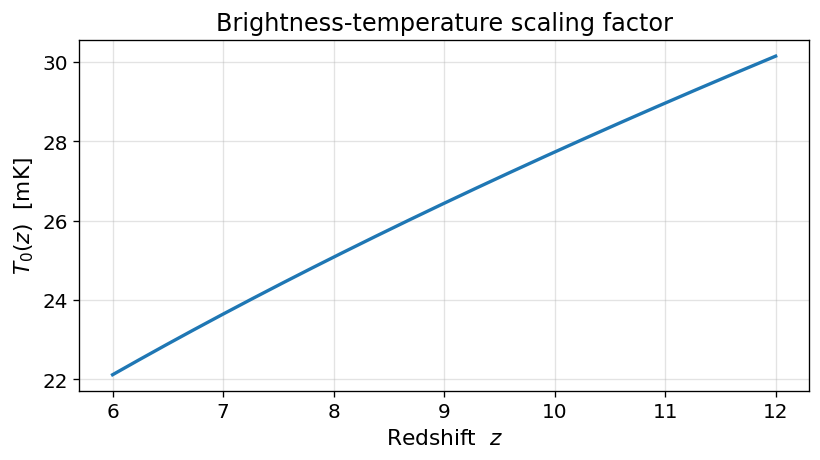

T0 at z = 8  : 25.08 mK
T0 at z = 10 : 27.73 mK


In [2]:
# ── Planck 2018 cosmological parameters ──────────────────────────────────────
# (Planck Collaboration 2020, Table 2: TT,TE,EE+lowE+lensing)
Omega_b_h2 = 0.02237   # Omega_b * h^2
Omega_m_h2 = 0.1430    # Omega_m * h^2
h_cosmo    = 0.6736    # (H0 = 67.36 h km/s/Mpc)


def T0(z, Omega_b_h2=Omega_b_h2, Omega_m_h2=Omega_m_h2, high_Ts=True):
    '''
    Brightness-temperature scaling factor T0(z) in milli-Kelvin.

    La Plante et al. (2023), Equation (6); originally from Madau et al. (1997).

    In the saturated-spin-temperature limit (T_S >> T_gamma, high_Ts=True)
    the (T_S - T_gamma)/T_S prefactor is set to 1.

    Parameters
    ----------
    z          : float or ndarray  -- cosmological redshift
    Omega_b_h2 : float  -- (Omega_b * h^2)
    Omega_m_h2 : float  -- (Omega_m * h^2)
    high_Ts    : bool   -- if True use the saturated spin-temp. approximation

    Returns
    -------
    T0 : float or ndarray  [mK]
    '''
    spin_factor = 1.0 if high_Ts else NotImplemented  # extend for cold reionization
    return (26.0
            * spin_factor
            * (Omega_b_h2 / 0.022)
            * np.sqrt((0.143 / Omega_m_h2) * (1.0 + z) / 10.0))


# ── Evaluate T0 across EoR redshifts ─────────────────────────────────────────
z_arr = np.linspace(6, 12, 200)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z_arr, T0(z_arr), lw=2)
ax.set_xlabel("Redshift  $z$")
ax.set_ylabel("$T_0(z)$  [mK]")
ax.set_title("Brightness-temperature scaling factor")
plt.tight_layout()
plt.show()

print(f"T0 at z = 8  : {T0(8):.2f} mK")
print(f"T0 at z = 10 : {T0(10):.2f} mK")


### 2b  Photometric Redshift Damping Kernel $W(k_\parallel)$

Photometric redshift surveys — such as the **Roman High-Latitude Wide Area Survey** considered
in La Plante et al. (2023) — measure galaxy redshifts from broadband photometry rather than
spectroscopy.  This introduces a Gaussian uncertainty $\sigma_z$ in each galaxy's redshift,
which smears its inferred line-of-sight (radial) position by a comoving distance

$$
\sigma_r(z) = \frac{c}{H(z)}\,\sigma_z \quad [h^{-1}\,\mathrm{Mpc}]
$$

where $H(z) = H_0\sqrt{\Omega_m(1+z)^3 + \Omega_\Lambda}$ is the Hubble parameter at redshift
$z$.  In Fourier space, this radial smearing suppresses modes along the line of sight via a
Gaussian damping kernel:

$$
W(k_\parallel) = \exp\!\left(-\frac{1}{2}\,k_\parallel^2\,\sigma_r^2\right)
$$

This kernel:
- equals **1** at $k_\parallel = 0$ (large-scale modes are unaffected)
- falls off rapidly at $k_\parallel \gtrsim 1/\sigma_r$ (small-scale radial modes are erased)
- becomes more severe at **lower redshift** (where $H(z)$ is smaller, so $\sigma_r$ is larger)
  and for larger **$\sigma_z$**

Typical values for Roman-like photometric surveys are $\sigma_z \approx 0.02$–$0.05$
(see Eifler et al. 2021; Wang et al. 2022).

### References
- **La Plante et al. (2023)** — [arXiv:2205.09770](https://arxiv.org/abs/2205.09770) — discusses
  galaxy survey requirements for 21cm cross-correlation including photo-z
- **Seo & Eisenstein (2003)** — [arXiv:astro-ph/0307460](https://arxiv.org/abs/astro-ph/0307460)
  — derivation of the line-of-sight damping from redshift uncertainty
- **Eifler et al. (2021)** — [arXiv:2004.05271](https://arxiv.org/abs/2004.05271) — Roman Space
  Telescope science requirements, including photo-z performance
- **Wang et al. (2022)** — [arXiv:2110.07418](https://arxiv.org/abs/2110.07418) — Roman grism
  spectroscopic and photometric redshift forecasts

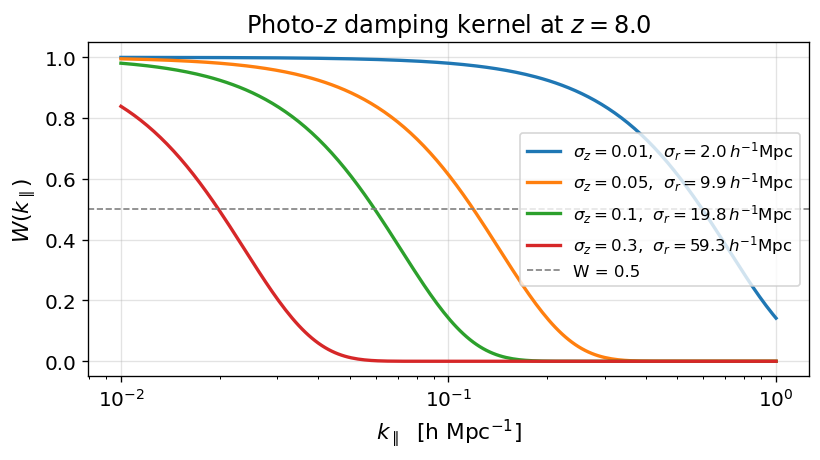


At z=8.0, sigma_r for each sigma_z:
  sigma_z = 0.01  =>  sigma_r = 1.98 h^-1 Mpc
  sigma_z = 0.05  =>  sigma_r = 9.88 h^-1 Mpc
  sigma_z = 0.10  =>  sigma_r = 19.76 h^-1 Mpc
  sigma_z = 0.30  =>  sigma_r = 59.29 h^-1 Mpc


In [3]:
# ── Section 2b: Hubble parameter H(z) needed for photo-z smearing ─────────────

def H_z(z, H0=67.36, Omega_m=0.1430/0.6736**2, Omega_Lambda=None):
    """
    Hubble parameter H(z) in km/s/Mpc (flat LCDM, Planck 2018).

    Parameters
    ----------
    z           : float or array  -- redshift
    H0          : float           -- Hubble constant [km/s/Mpc]
    Omega_m     : float           -- matter density parameter
    Omega_Lambda: float or None   -- if None, flat universe => Omega_Lambda = 1 - Omega_m

    Returns
    -------
    H : float or array  [km/s/Mpc]
    """
    if Omega_Lambda is None:
        Omega_Lambda = 1.0 - Omega_m
    return H0 * np.sqrt(Omega_m * (1 + z)**3 + Omega_Lambda)


def sigma_r(z, sigma_z):
    """
    Comoving line-of-sight smearing from photo-z error sigma_z.

    sigma_r = (c / H(z)) * sigma_z       [h^-1 Mpc]

    Note: c in km/s, H(z) in km/s/Mpc => sigma_r in Mpc.
    Multiply by h to get h^-1 Mpc to match k units in h/Mpc.

    Parameters
    ----------
    z       : float  -- redshift
    sigma_z : float  -- photo-z uncertainty (e.g. 0.05 means delta-z = 0.05)

    Returns
    -------
    sr : float  [h^-1 Mpc]
    """
    c_kms = 3e5               # speed of light [km/s]
    sr_Mpc = (c_kms / H_z(z)) * sigma_z
    return sr_Mpc * h_cosmo   # convert to h^-1 Mpc to match k in h/Mpc


def W_photoz(k_par, z, sigma_z):
    """
    Gaussian photo-z damping kernel W(k_par).

        W(k_par) = exp(-0.5 * k_par^2 * sigma_r^2)

    Parameters
    ----------
    k_par   : array  -- line-of-sight wavenumber [h/Mpc]
    z       : float  -- redshift
    sigma_z : float  -- photo-z uncertainty

    Returns
    -------
    W : array, same shape as k_par  (values in [0, 1])
    """
    sr = sigma_r(z, sigma_z)
    return np.exp(-0.5 * k_par**2 * sr**2)


# ── Quick diagnostic: damping at z=8 for different sigma_z ───────────────────
k_par_test = np.logspace(-2, 0, 200)
z_test     = 8.0

fig, ax = plt.subplots(figsize=(7, 4))
for sz in [0.01, 0.05, 0.1, 0.3]:
    sr = sigma_r(z_test, sz)
    W  = W_photoz(k_par_test, z_test, sz)
    ax.semilogx(k_par_test, W, lw=2,
                label=rf"$\sigma_z={sz}$,  $\sigma_r={sr:.1f}\,h^{{-1}}$Mpc")

ax.axhline(0.5, color='grey', ls='--', lw=1, label='W = 0.5')
ax.set_xlabel(r"$k_\parallel$  [h Mpc$^{-1}$]")
ax.set_ylabel(r"$W(k_\parallel)$")
ax.set_title(rf"Photo-$z$ damping kernel at $z={z_test}$")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nAt z={z_test}, sigma_r for each sigma_z:")
for sz in [0.01, 0.05, 0.1, 0.3]:
    print(f"  sigma_z = {sz:.2f}  =>  sigma_r = {sigma_r(z_test, sz):.2f} h^-1 Mpc")

## 3  Proxy power spectra

Because we do not have simulation output here, we replace the true power spectra with
**arbitrary mathematical models** that reproduce their qualitative features:

* **Power-law shape** — cosmological power spectra are approximately power laws in $k$ on
  the scales of interest.
* **Anti-correlation** — $P_{21\times\mathrm{gal}}$ is *negative* on large scales (the
  21 cm and galaxy fields are anti-correlated during reionization).
* **Noise rising at high $k$** — 21 cm thermal noise grows towards smaller scales.

### 3a  The CDM Matter Power Spectrum — BBKS Transfer Function

All three signal spectra are physically derived from the **CDM matter power spectrum**
$P_m(k)$, which has the well-known shape:

$$
P_m(k) = A \, k^{n_s} \, T(k)^2 \, D(z)^2
$$

where:
- $A$ is a normalisation constant fixed by $\sigma_8$
- $n_s = 0.9649$ is the scalar spectral index (Planck 2018)
- $T(k)$ is the CDM transfer function — encodes the suppression of sub-horizon modes that
  entered the horizon during radiation domination
- $D(z)$ is the linear growth factor, normalised to $D(0) = 1$

The transfer function is computed using the **BBKS fitting formula**
(Bardeen, Bond, Kaiser & Szalay 1986):

$$
T(q) = \frac{\ln(1 + 2.34q)}{2.34q}
\left[1 + 3.89q + (16.1q)^2 + (5.46q)^3 + (6.71q)^4\right]^{-1/4}
$$

where $q = k/\Gamma$ and the shape parameter is
$\Gamma = \Omega_m h \exp\!\left[-\Omega_b\!\left(1 + \sqrt{2h}/\Omega_m\right)\right]$.
The amplitude $A$ is fixed by requiring $\sigma_8 = 0.811$ at $z=0$ (Planck 2018).

The growth factor $D(z)$ is computed using the Carroll, Press & Turner (1992) fitting formula,
which is accurate to better than 1% for flat $\Lambda$CDM.

This gives a realistic CDM shape with:
- A **turnover** at $k_{\rm eq} \sim 0.01$–$0.02\,h\,{\rm Mpc}^{-1}$ (matter–radiation equality scale)
- A **$k^{n_s - 4}$ tail** at high $k$ from the transfer function suppression
- **Correct amplitude** set by $\sigma_8$

### References
- **Bardeen, Bond, Kaiser & Szalay (1986)**, ApJ, 304, 15 — BBKS transfer function fitting formula
- **Carroll, Press & Turner (1992)**, ARA&A, 30, 499 — growth factor fitting formula
- **Planck Collaboration (2020)**, A&A, 641, A6 — $n_s$, $\sigma_8$, cosmological parameters
  ([arXiv:1807.06209](https://arxiv.org/abs/1807.06209))

### Noise power spectra

**21 cm thermal noise** (proxy for Eq. 11 of the paper, which gives the full interferometer
noise model):

$$P_{21}^{\mathrm{noise}}(k_\perp, k_\parallel) = N_{21}\, k^{+\beta_{21}}$$

The positive slope ($\beta_{21} > 0$) captures the physical expectation that thermal noise
rises at smaller scales (higher $k$).

**Galaxy shot noise** — Poisson noise from the discrete sampling of the galaxy field.
In the limit of a large survey volume this is white noise with amplitude $1/\bar{n}$,
where $\bar{n}$ is the mean comoving galaxy number density:

$$P_{\mathrm{gal}}^{\mathrm{noise}} = \frac{1}{\bar{n}}$$


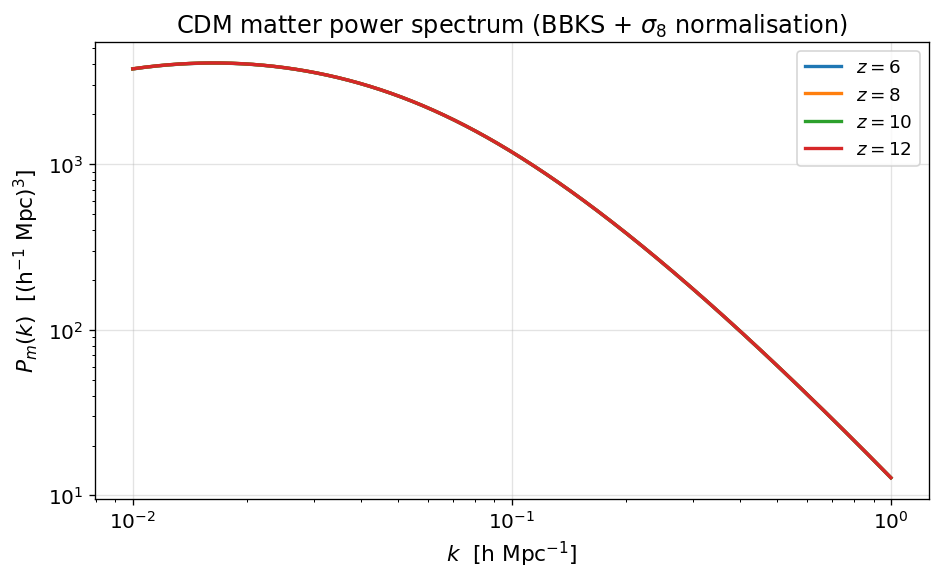

Omega_m  = 0.3152
Omega_b  = 0.0493
Gamma    = 0.1685
D(z=8)   = 1.2698
P_m(k=0.1, z=8) = 1.18e+03  (h^-1 Mpc)^3


In [4]:
# ── Section 3a: CDM matter power spectrum via BBKS transfer function ──────────

# Derived cosmological parameters from Planck 2018
Omega_m = Omega_m_h2 / h_cosmo**2     # ~ 0.3153
Omega_b = Omega_b_h2 / h_cosmo**2     # ~ 0.0493
Omega_L = 1.0 - Omega_m               # flat LCDM
n_s     = 0.9649                      # scalar spectral index
sigma_8 = 0.811                       # matter fluctuation amplitude


def transfer_BBKS(k):
    """
    BBKS CDM transfer function (Bardeen et al. 1986).

    Parameters
    ----------
    k : array  -- wavenumber [h/Mpc]

    Returns
    -------
    T : array  -- transfer function T(k), dimensionless
    """
    # Shape parameter (Sugiyama 1995 correction for baryon fraction)
    Gamma = Omega_m * h_cosmo * np.exp(
        -Omega_b * (1.0 + np.sqrt(2.0 * h_cosmo) / Omega_m)
    )
    q = k / Gamma
    # Avoid divide-by-zero at k=0
    q = np.where(q == 0, 1e-10, q)
    T = (np.log(1.0 + 2.34 * q) / (2.34 * q) *
         (1.0 + 3.89*q + (16.1*q)**2 + (5.46*q)**3 + (6.71*q)**4)**(-0.25))
    return T


def growth_factor(z):
    """
    Linear growth factor D(z), normalised to D(z=0) = 1.
    Carroll, Press & Turner (1992) fitting formula for flat LCDM.

    Parameters
    ----------
    z : float or array  -- redshift

    Returns
    -------
    D : float or array  -- growth factor (dimensionless)
    """
    def D_unnorm(z_):
        Om_z = Omega_m * (1 + z_)**3 / (Omega_m * (1 + z_)**3 + Omega_L)
        OL_z = Omega_L / (Omega_m * (1 + z_)**3 + Omega_L)
        return ((5.0 * Om_z / 2.0) /
                (Om_z**(4.0/7.0) - OL_z + (1.0 + Om_z/2.0) * (1.0 + OL_z/70.0)))
    return D_unnorm(z) / D_unnorm(0.0)


def P_matter(k, z):
    """
    CDM matter power spectrum P_m(k, z) [h^-3 Mpc^3], BBKS + sigma_8 normalisation.

    Parameters
    ----------
    k : array  -- wavenumber [h/Mpc]
    z : float  -- redshift

    Returns
    -------
    Pm : array, same shape as k  [(h^-1 Mpc)^3]
    """
    T = transfer_BBKS(k)
    P_unnorm = k**n_s * T**2

    # Normalise to sigma_8 at z=0 by integrating over tophat window of R=8 h^-1 Mpc
    k_int = np.logspace(-4, 2, 4000)
    T_int = transfer_BBKS(k_int)
    P_int = k_int**n_s * T_int**2
    x = k_int * 8.0   # k * R,  R = 8 h^-1 Mpc
    W = 3.0 * (np.sin(x) - x * np.cos(x)) / x**3
    sigma8_sq_unnorm = np.trapz(k_int**2 * P_int * W**2, np.log(k_int)) / (2.0 * np.pi**2)
    A_norm = sigma_8**2 / sigma8_sq_unnorm

    return A_norm * growth_factor(z)**2 * P_unnorm


# ── Evaluate and plot P_m(k) at several EoR redshifts ────────────────────────
k_1d = np.logspace(-2, 0, 500)

fig, ax = plt.subplots(figsize=(8, 5))
for z_plt in [6, 8, 10, 12]:
    ax.loglog(k_1d, P_matter(k_1d, z_plt), lw=2, label=f"$z = {z_plt}$")

ax.set_xlabel(r"$k$  [h Mpc$^{-1}$]")
ax.set_ylabel(r"$P_m(k)$  [(h$^{-1}$ Mpc)$^3$]")
ax.set_title("CDM matter power spectrum (BBKS + $\\sigma_8$ normalisation)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Omega_m  = {Omega_m:.4f}")
print(f"Omega_b  = {Omega_b:.4f}")
print(f"Gamma    = {Omega_m * h_cosmo * np.exp(-Omega_b*(1+np.sqrt(2*h_cosmo)/Omega_m)):.4f}")
print(f"D(z=8)   = {growth_factor(8):.4f}")
print(f"P_m(k=0.1, z=8) = {P_matter(0.1, 8):.2e}  (h^-1 Mpc)^3")

### 3b  Physical Signal Power Spectra — Lidz et al. (2009) Bias Model

Following **Lidz et al. (2009)** [arXiv:0806.1055], all three signal spectra are expressed
as biased tracers of the matter power spectrum, with a scale-dependent suppression from the
characteristic size of ionized bubbles during reionization.

#### Model

The 21 cm brightness temperature fluctuation field can be written as:

$$
\delta_{21}(\mathbf{k}) = x_{\rm HI} \left[ b_\rho \, \delta_m(\mathbf{k})
+ b_x \, \delta_x(\mathbf{k}) \right]
$$

where $\delta_m$ is the matter overdensity, $\delta_x$ is the ionization field fluctuation,
$b_\rho = 1$ is the density bias, and $b_x$ is the ionization bias (negative, since
overdense regions become ionized first in the inside-out reionization scenario).

The **ionization field** is correlated with the matter field on scales larger than the
characteristic bubble radius $R_b$, and decorrelated on smaller scales.  This is captured
by a Gaussian bubble window function:

$$
W_b(k) = \exp\!\left(-\frac{1}{2} k^2 R_b^2\right)
$$

The three spectra are then (Lidz et al. 2009, Eqs. 2–5):

$$
P_{21}(k) = T_0^2 \, x_{\rm HI}^2 \left(b_\rho + b_x W_b\right)^2 P_m(k)
$$

$$
P_{\rm gal}(k) = b_{\rm gal}^2 \, P_m(k)
$$

$$
P_{21\times{\rm gal}}(k) = T_0 \, x_{\rm HI} \, b_{\rm gal}
\left(b_\rho + b_x W_b\right) P_m(k)
$$

The cross-spectrum is **negative** on large scales (where $|b_x| > b_\rho$) because
detectable galaxies sit preferentially in ionized regions that are 21 cm-dark.
On scales $k \gg 1/R_b$, the bubble window suppresses the ionization bias term and
the cross-spectrum approaches $T_0 x_{\rm HI} b_\rho b_{\rm gal} P_m > 0$.
The **scale of the turnover** in the cross-spectrum traces the growing bubble size as
reionization proceeds, which is one of the key observables of this cross-correlation.

#### Physical parameter choices (fiducial, $z=8$, $\bar{x}_{\rm HI} = 0.5$)

| Parameter | Value | Physical meaning |
|-----------|-------|-----------------|
| $x_{\rm HI}$ | 0.5 | Mean neutral fraction at mid-reionization |
| $b_\rho$ | 1.0 | 21 cm density bias (neutral gas traces mass) |
| $b_x$ | $-5.0$ | Ionization bias (inside-out: ionized $\leftrightarrow$ overdense) |
| $b_{\rm gal}$ | 5.0 | Galaxy bias (bright high-$z$ galaxies in massive halos) |
| $R_b$ | $10\,h^{-1}$Mpc | Characteristic bubble radius at $\bar{x}_{\rm HI} = 0.5$ |
| $\bar{n}_{\rm gal}$ | $10^{-3}\,h^3{\rm Mpc}^{-3}$ | Galaxy number density |

#### References
- **Lidz et al. (2009)**, ApJ, 690, 252 — [arXiv:0806.1055](https://arxiv.org/abs/0806.1055)
  — physical model for all three spectra; the primary source for this section
- **Furlanetto & Lidz (2007)**, ApJ, 660, 1030 — derivation of the bubble window function
  and its relation to the cross-spectrum turnover scale
- **Mesinger & Furlanetto (2007)**, ApJ, 669, 663 — semi-numerical reionization showing
  bubble sizes of $\sim 5$–$20\,h^{-1}$ Mpc at mid-reionization
- **Sobacchi et al. (2016)**, MNRAS, 459, 2741 — updated observational forecasts using
  this bias framework

In [5]:
# Fix the observing redshift to z = 8 (mid-reionization in the paper's fiducial model)
z_obs  = 8.0
T0_val = T0(z_obs)
print(f"Evaluating uncertainties at z = {z_obs}")
print(f"T0(z={z_obs}) = {T0_val:.3f} mK")


Evaluating uncertainties at z = 8.0
T0(z=8.0) = 25.081 mK


## 2c  Fourier-space grid and helper functions

We set up a 2-D logarithmic grid in $(k_\perp, k_\parallel)$ and define
a simple power-law helper used for proxy/noise spectra.


In [6]:
# ── Fourier-space grid ────────────────────────────────────────────────────────
N = 128                                       # grid resolution per axis
k_perp_1d = np.logspace(-2, 0, N)             # k_perp [h/Mpc]
k_par_1d  = np.logspace(-2, 0, N)             # k_par  [h/Mpc]
k_perp, k_par = np.meshgrid(k_perp_1d, k_par_1d, indexing='ij')  # (N, N)
k_tot = np.sqrt(k_perp**2 + k_par**2)         # total wavenumber


def power_law(k, amplitude, slope):
    '''
    Simple power-law spectrum:  P(k) = amplitude * k^(-slope).

    Parameters
    ----------
    k         : array  -- wavenumber [h/Mpc]
    amplitude : float  -- normalisation
    slope     : float  -- power-law index (positive = red spectrum)

    Returns
    -------
    P : array, same shape as k
    '''
    return amplitude * k**(-slope)


print(f"Grid: {N} x {N} modes")
print(f"k_perp range: [{k_perp_1d[0]:.4f}, {k_perp_1d[-1]:.4f}] h/Mpc")
print(f"k_par  range: [{k_par_1d[0]:.4f},  {k_par_1d[-1]:.4f}] h/Mpc")


Grid: 128 x 128 modes
k_perp range: [0.0100, 1.0000] h/Mpc
k_par  range: [0.0100,  1.0000] h/Mpc


Physical spectra at k_perp = k_par = 0.032 h/Mpc:
  W_b(k)         = 0.9032  (bubble suppression)
  b_21_eff(k)    = -3.5159  (effective 21cm bias)
  P_m(k)         = 2.80e+03  (h^-1 Mpc)^3
  P21            = 5.45e+06  mK^2 (h^-1 Mpc)^3
  P_gal          = 7.01e+04  (h^-1 Mpc)^3
  P21_gal        = -6.18e+05  mK (h^-1 Mpc)^3  [negative = anticorr.]
  P21_noise      = 1.06e+07  mK^2 (h^-1 Mpc)^3
  P_gal_noise    = 1.00e+03  (h^-1 Mpc)^3

Cross-spectrum sign: NEGATIVE (anticorrelated) ✓


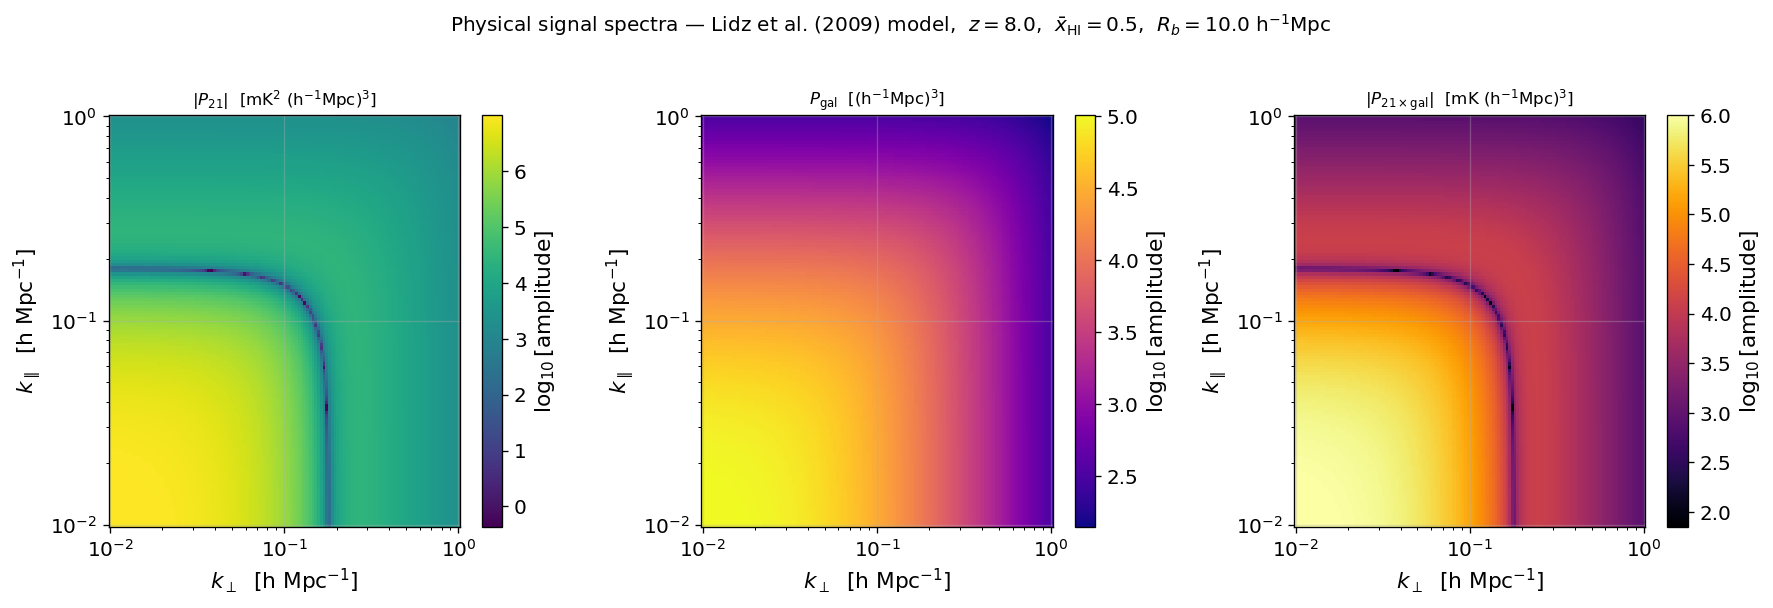

In [7]:
# ── Section 3b: Physical signal spectra — Lidz et al. (2009) model ───────────
# This REPLACES the proxy power_law() spectra from the original Section 3.
# Variable names (P21, P_gal, P21_gal, P21_noise, P_gal_noise) are preserved
# so all downstream cells (Sections 4–11) work without modification.

# ── Reionization and bias parameters ─────────────────────────────────────────
x_HI   = 0.5    # mean neutral fraction at mid-reionization (z~8)
b_rho  = 1.0    # 21cm density bias
b_x    = -5.0   # ionization bias (negative: inside-out reionization)
b_gal  = 5.0    # galaxy bias (bright high-z dropout galaxies in massive halos)
R_b    = 10.0   # characteristic bubble radius [h^-1 Mpc]
n_bar_gal = 1e-3  # mean galaxy number density [h^3 Mpc^-3]

# ── HERA-like 21cm noise parameters ──────────────────────────────────────────
# Simplified noise model: thermal noise amplitude and slope
# Replace with the full Eq.11 of La Plante et al. (2023) for a physical result
T_sys   = 1000.0   # system temperature [mK] (dominated by sky at ~150 MHz)
t_int   = 1000.0   # integration time [hours]
A_noise = T_sys**2 / t_int * 5e4   # rough amplitude scaling [mK^2 (h^-1 Mpc)^3]
beta_noise = -0.5  # noise grows at high k (fewer baselines at short spacings)

# ── Recompute P_m on the full 2D (k_perp, k_par) grid ────────────────────────
Pm_2d = P_matter(k_tot, z_obs)   # shape (N, N), uses k_tot = sqrt(k_perp^2+k_par^2)

# ── Bubble window function W_b(k_par) ─────────────────────────────────────────
# Depends only on k_par: radial modes decorrelate at bubble scale
# (transverse modes less affected since bubbles are roughly spherical)
# For a fully isotropic model, use k_tot instead of k_par
W_b = np.exp(-0.5 * k_tot**2 * R_b**2)   # shape (N, N)

# ── Effective 21cm bias (scale-dependent) ────────────────────────────────────
b_21_eff = b_rho + b_x * W_b              # shape (N, N)

# ── Signal spectra (Lidz et al. 2009, Eqs. 2-5) ──────────────────────────────
P21     = T0_val**2 * x_HI**2 * b_21_eff**2 * Pm_2d          # [mK^2 (h^-1 Mpc)^3]
P_gal   = b_gal**2 * Pm_2d                                    # [(h^-1 Mpc)^3]
P21_gal = T0_val * x_HI * b_gal * b_21_eff * Pm_2d           # [mK (h^-1 Mpc)^3]
# Note: P21_gal is negative on large scales (b_21_eff < 0 there) — anticorrelated

# ── Noise spectra ─────────────────────────────────────────────────────────────
P21_noise   = power_law(k_tot, A_noise, beta_noise)           # HERA thermal noise proxy
P_gal_noise = np.full_like(k_tot, 1.0 / n_bar_gal)           # shot noise

# ── Sanity checks ─────────────────────────────────────────────────────────────
idx = (N//4, N//4)
print(f"Physical spectra at k_perp = k_par = {k_perp_1d[N//4]:.3f} h/Mpc:")
print(f"  W_b(k)         = {W_b[idx]:.4f}  (bubble suppression)")
print(f"  b_21_eff(k)    = {b_21_eff[idx]:.4f}  (effective 21cm bias)")
print(f"  P_m(k)         = {Pm_2d[idx]:.2e}  (h^-1 Mpc)^3")
print(f"  P21            = {P21[idx]:.2e}  mK^2 (h^-1 Mpc)^3")
print(f"  P_gal          = {P_gal[idx]:.2e}  (h^-1 Mpc)^3")
print(f"  P21_gal        = {P21_gal[idx]:.2e}  mK (h^-1 Mpc)^3  [negative = anticorr.]")
print(f"  P21_noise      = {P21_noise[idx]:.2e}  mK^2 (h^-1 Mpc)^3")
print(f"  P_gal_noise    = {P_gal_noise[idx]:.2e}  (h^-1 Mpc)^3")
print(f"\nCross-spectrum sign: {'NEGATIVE (anticorrelated) ✓' if P21_gal[idx] < 0 else 'POSITIVE'}")

# ── Plot the three signal spectra on the 2D grid ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

panels = [
    (np.abs(P21),     r"$|P_{21}|$  [mK$^2$ (h$^{-1}$Mpc)$^3$]",       "viridis"),
    (np.abs(P_gal),   r"$P_{\rm gal}$  [(h$^{-1}$Mpc)$^3$]",            "plasma"),
    (np.abs(P21_gal), r"$|P_{21\times{\rm gal}}|$  [mK (h$^{-1}$Mpc)$^3$]", "inferno"),
]

for ax, (data, title, cmap) in zip(axes, panels):
    im = ax.pcolormesh(k_perp_1d, k_par_1d, np.log10(data.T),
                       cmap=cmap, shading="auto")
    cb = fig.colorbar(im, ax=ax)
    cb.set_label(r"$\log_{10}$[amplitude]")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$k_\perp$  [h Mpc$^{-1}$]")
    ax.set_ylabel(r"$k_\parallel$  [h Mpc$^{-1}$]")
    ax.set_title(title, fontsize=10)

plt.suptitle(
    rf"Physical signal spectra — Lidz et al. (2009) model,  $z={z_obs}$,  "
    rf"$\bar{{x}}_{{\rm HI}}={x_HI}$,  $R_b={R_b}$ h$^{{-1}}$Mpc",
    y=1.01, fontsize=12
)
plt.tight_layout()
plt.show()

### 3.1  Visualise the proxy power spectra

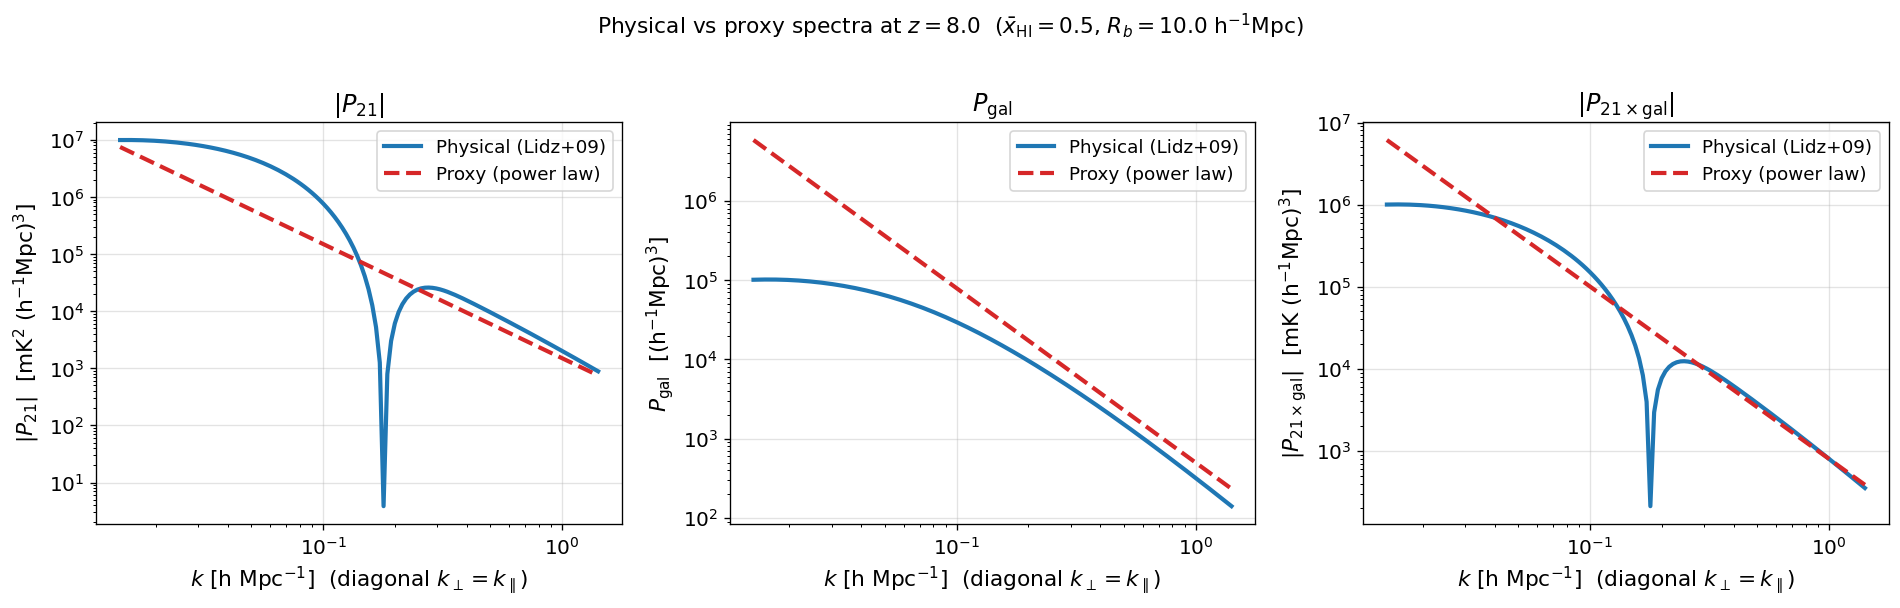

Cross-spectrum sign change at k ~ 0.179 h/Mpc
Characteristic bubble scale 1/R_b = 0.100 h/Mpc


In [8]:
# ── Section 3c: Compare physical vs proxy spectra along k_perp = k_par diagonal

# Proxy spectra (from original notebook, recomputed for comparison)
A_21_proxy    = 1.5e3;  alpha_21_proxy   = 2.0
A_gal_proxy   = 5.0e2;  alpha_gal_proxy  = 2.2
A_cross_proxy = 8.0e2;  alpha_cross_proxy = 2.1

P21_proxy     =  power_law(k_tot, A_21_proxy,    alpha_21_proxy)
P_gal_proxy   =  power_law(k_tot, A_gal_proxy,   alpha_gal_proxy)
P21_gal_proxy = -power_law(k_tot, A_cross_proxy,  alpha_cross_proxy)

# Diagonal
diag = np.arange(N)
k_d  = k_tot[diag, diag]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = [
    (np.abs(P21[diag,diag]),       np.abs(P21_proxy[diag,diag]),
     r"$|P_{21}|$",                "mK$^2$ (h$^{-1}$Mpc)$^3$"),
    (np.abs(P_gal[diag,diag]),     np.abs(P_gal_proxy[diag,diag]),
     r"$P_{\rm gal}$",             "(h$^{-1}$Mpc)$^3$"),
    (np.abs(P21_gal[diag,diag]),   np.abs(P21_gal_proxy[diag,diag]),
     r"$|P_{21\times{\rm gal}}|$", "mK (h$^{-1}$Mpc)$^3$"),
]

for ax, (phys, proxy, title, unit) in zip(axes, labels):
    ax.loglog(k_d, phys,  lw=2.5, color="C0", label="Physical (Lidz+09)")
    ax.loglog(k_d, proxy, lw=2.5, color="C3", ls="--", label="Proxy (power law)")
    ax.set_xlabel(r"$k$ [h Mpc$^{-1}$]  (diagonal $k_\perp = k_\parallel$)")
    ax.set_ylabel(f"{title}  [{unit}]")
    ax.set_title(title)
    ax.legend()

plt.suptitle(
    rf"Physical vs proxy spectra at $z={z_obs}$  "
    rf"($\bar{{x}}_{{\rm HI}}={x_HI}$, $R_b={R_b}$ h$^{{-1}}$Mpc)",
    y=1.01, fontsize=13
)
plt.tight_layout()
plt.show()

# Show where cross-spectrum changes sign
sign_change = np.where(np.diff(np.sign(P21_gal[diag, diag])))[0]
if len(sign_change) > 0:
    k_turnover = k_d[sign_change[0]]
    print(f"Cross-spectrum sign change at k ~ {k_turnover:.3f} h/Mpc")
    print(f"Characteristic bubble scale 1/R_b = {1/R_b:.3f} h/Mpc")
else:
    print("Cross-spectrum does not change sign on this k range")
    print(f"Large-scale b_21_eff = {(b_rho + b_x):.2f}  "
          f"({'negative = anticorrelated ✓' if b_rho + b_x < 0 else 'positive'})")

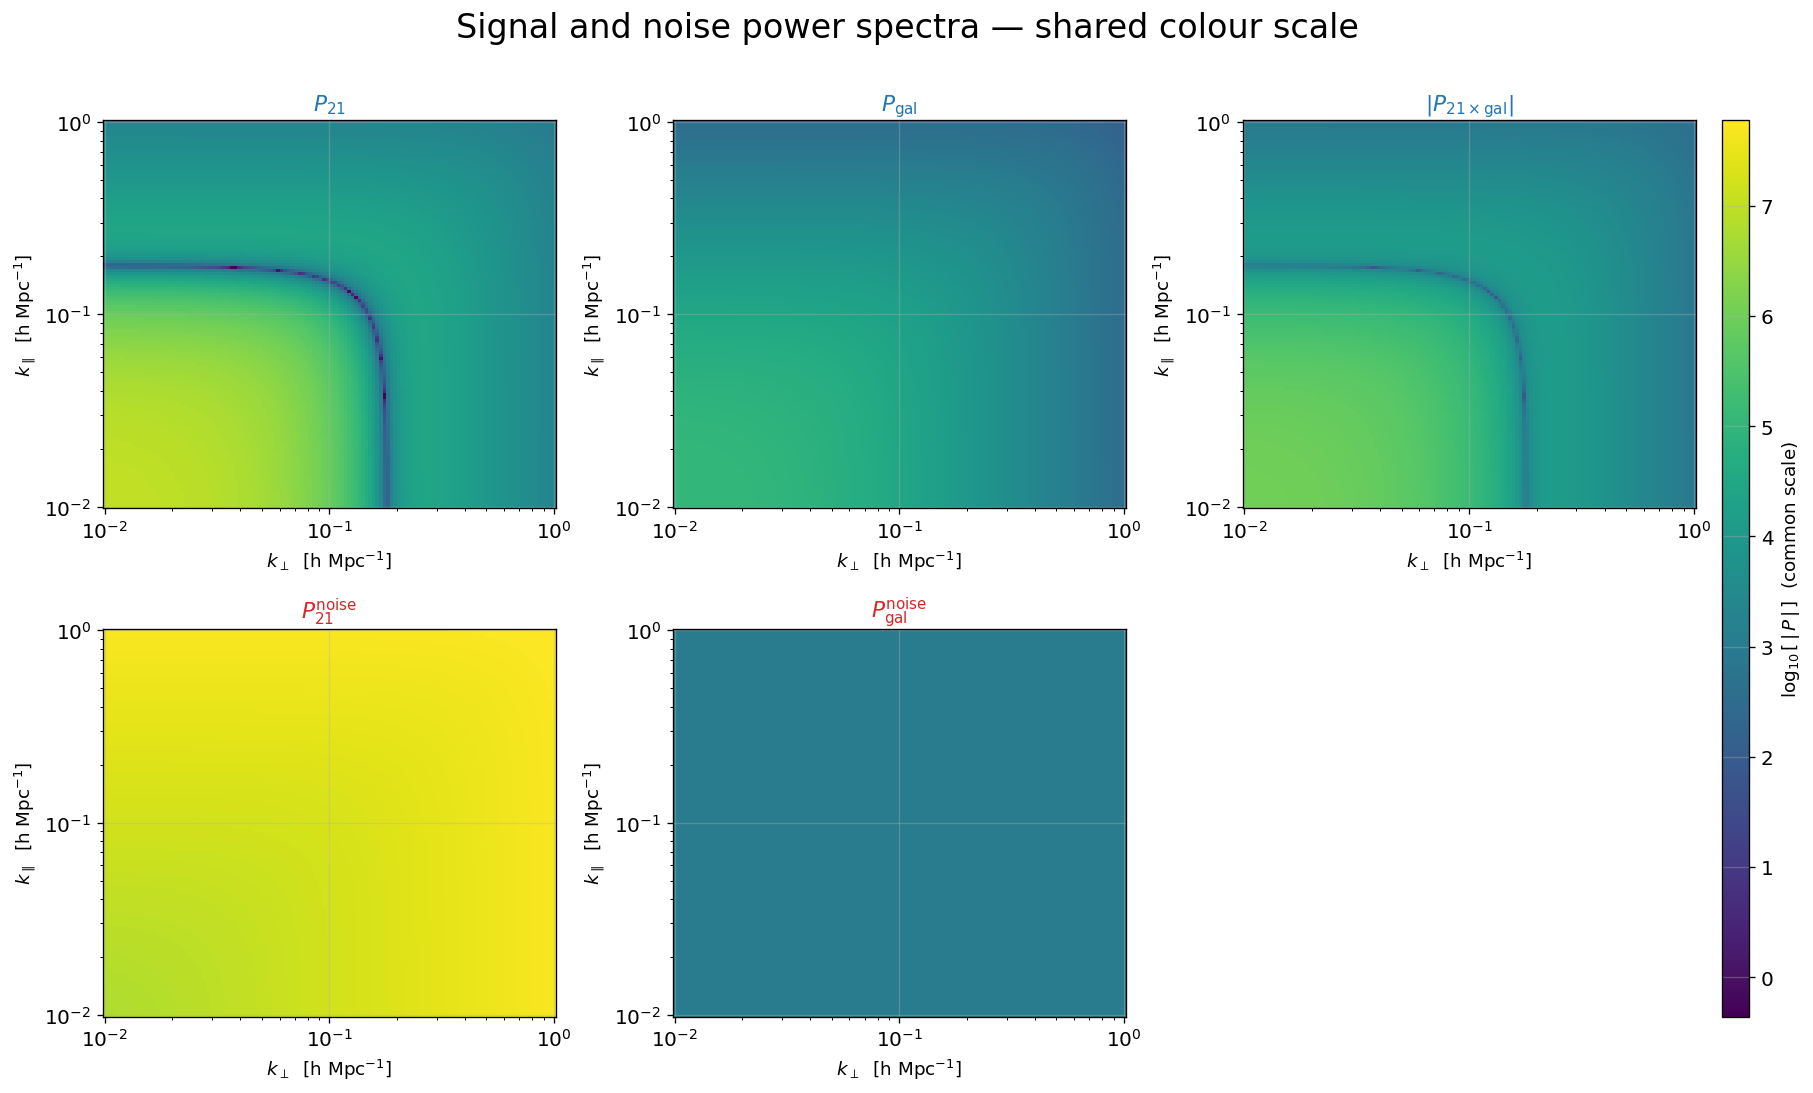

In [9]:

# ── Shared colour scale: signal spectra + noise spectra on one colourmap ──────
# Using absolute values so log10 is well-defined; P21_gal is negative (anti-corr.)

datasets = [
    (np.abs(P21),         r"$P_{21}$",                       "Signal"),
    (np.abs(P_gal),       r"$P_{\rm gal}$",                  "Signal"),
    (np.abs(P21_gal),     r"$|P_{21\times{\rm gal}}|$",      "Signal"),
    (np.abs(P21_noise),   r"$P_{21}^{\rm noise}$",           "Noise"),
    (np.abs(P_gal_noise), r"$P_{\rm gal}^{\rm noise}$",      "Noise"),
]

log_data = [np.log10(d) for d, _, _ in datasets]

# Shared colour limits
vmin = min(ld.min() for ld in log_data)
vmax = max(ld.max() for ld in log_data)
cmap = "viridis"

# GridSpec: 2 rows × 3 data columns + 1 narrow colorbar column
fig = plt.figure(figsize=(15, 9), constrained_layout=True)
gs  = GridSpec(2, 4, figure=fig, width_ratios=[1, 1, 1, 0.06])

ax_positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]
axes    = [fig.add_subplot(gs[r, c]) for r, c in ax_positions]
cbar_ax = fig.add_subplot(gs[:, 3])   # colorbar spans both rows

for ax, (ld, title, kind) in zip(axes, zip(log_data, [t for _, t, _ in datasets],
                                             [k for _, _, k in datasets])):
    im = ax.pcolormesh(k_perp_1d, k_par_1d, ld.T,
                       cmap=cmap, shading="auto", vmin=vmin, vmax=vmax)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$k_\perp$  [h Mpc$^{-1}$]", fontsize=11)
    ax.set_ylabel(r"$k_\parallel$  [h Mpc$^{-1}$]", fontsize=11)
    # Colour-code title by signal vs noise
    title_colour = "C0" if kind == "Signal" else "C3"
    ax.set_title(title, fontsize=13, color=title_colour, fontweight="bold")

# Shared colorbar in the dedicated column
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"$\log_{10}[\,|\,P\,|\,]$  (common scale)", fontsize=11)

# Legend explaining title colours
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="C0", lw=3, label="Signal"),
    Line2D([0], [0], color="C3", lw=3, label="Noise"),
]
# fig.legend(handles=legend_elements, loc="lower right",
        #    bbox_to_anchor=(0.87, 0.08), fontsize=11, framealpha=0.85)

fig.suptitle(
    "Signal and noise power spectra — shared colour scale\n",
    # r"($|P_{21\times{\rm gal}}|$ shown; sign is negative = anti-correlated)",
    fontsize=20
)
plt.show()

# Summary table
# print(f"\n{'Spectrum':<28}  {'Kind':<7}  log10 min   log10 max")
# print("-" * 57)
# for ld, (_, title, kind) in zip(log_data, datasets):
    # print(f"{title:<28}  {kind:<7}  {ld.min():+.2f}       {ld.max():+.2f}")


### 3b  Applying Photo-$z$ Damping to the Observed Power Spectra

The photo-$z$ damping kernel $W(k_\parallel)$ affects the **galaxy** fields but not the
**21 cm** field, since the 21 cm brightness temperature is measured in frequency space (which
maps directly to redshift) with essentially perfect radial resolution set by the channel width.

The three power spectra transform as follows:

| Spectrum | Observed form | Reason |
|----------|--------------|--------|
| $P_{21}(k_\perp, k_\parallel)$ | unchanged | 21 cm has no photo-$z$ error |
| $P_\mathrm{gal}(k_\perp, k_\parallel)$ | $P_\mathrm{gal} \cdot W^2$ | both galaxies in the auto-pair are smeared |
| $P_{21\times\mathrm{gal}}(k_\perp, k_\parallel)$ | $P_{21\times\mathrm{gal}} \cdot W$ | only the galaxy field is smeared; 21 cm side is exact |

The suppression is **purely radial** — $W$ depends only on $k_\parallel$, so transverse
($k_\perp$) modes are completely unaffected.  At high $k_\parallel$, the galaxy auto-spectrum
is suppressed by $W^2$ while the cross-spectrum is suppressed only by $W$, meaning the cross-
correlation is **less degraded** by photo-$z$ errors than the galaxy auto-correlation.  This is
one of the practical advantages of the cross-correlation approach.

### References
- **Seljak (1998)** — [arXiv:astro-ph/9711124](https://arxiv.org/abs/astro-ph/9711124) — early
  treatment of redshift-space distortions and photo-$z$ damping in power spectrum analysis
- **Huterer et al. (2004)** — [arXiv:astro-ph/0404062](https://arxiv.org/abs/astro-ph/0404062)
  — impact of photo-$z$ errors on cross-correlations; establishes the $W$ vs $W^2$ asymmetry
- **Loverde & Afshordi (2008)** — [arXiv:0803.1922](https://arxiv.org/abs/0803.1922) — extended
  Limber approximation for cross-correlations with photo-$z$ uncertainty

Photo-z parameters at z=8.0:
  sigma_z = 0.05
  sigma_r = 9.881 h^-1 Mpc

Damping W at k_par = 0.1 h/Mpc : 0.6137
Damping W at k_par = 0.5 h/Mpc : 0.0000
Damping W at k_par = 1.0 h/Mpc : 0.0000


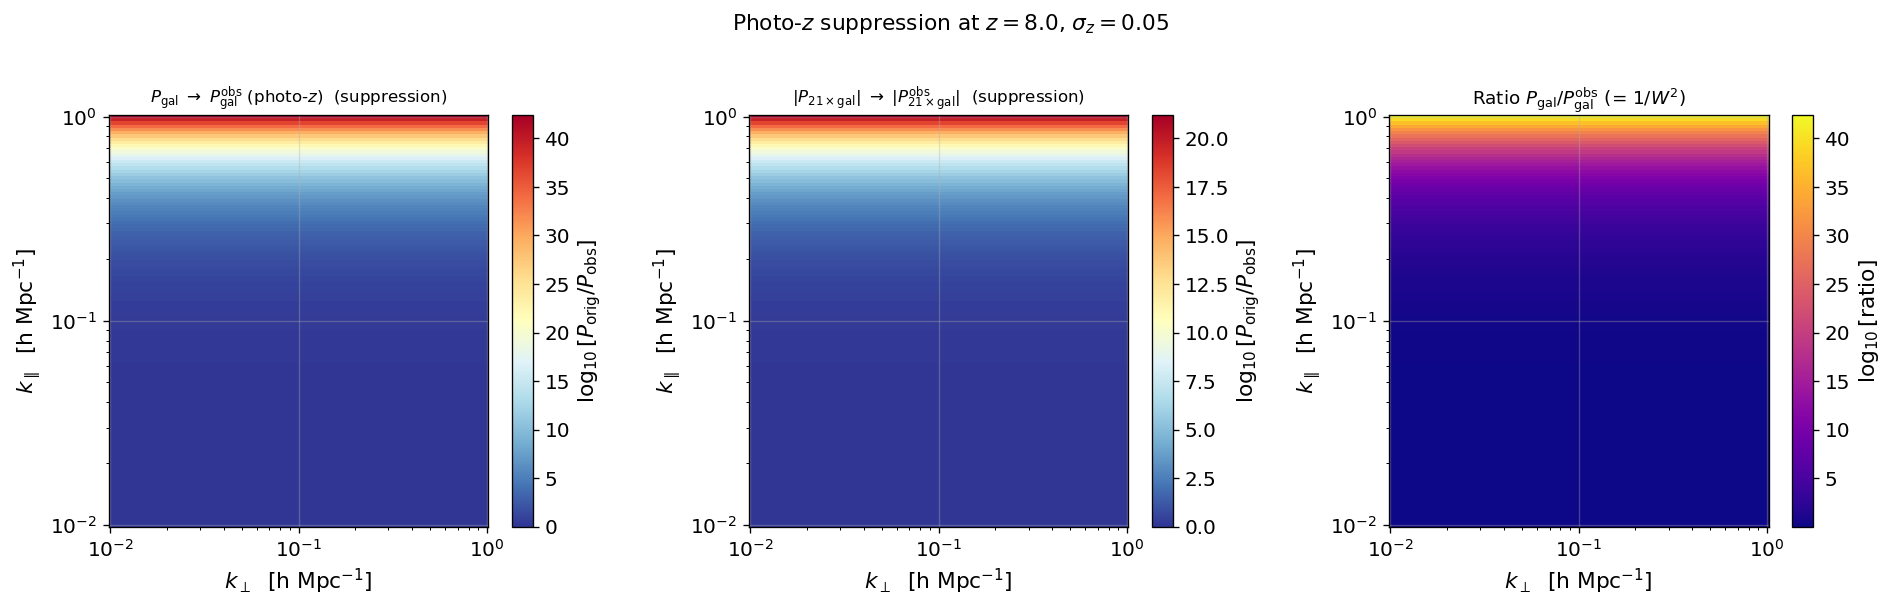

In [10]:
# ── Section 3b: Apply photo-z damping to observed spectra ────────────────────
# Choose a fiducial photo-z error — typical for Roman/Euclid-like surveys
sigma_z_phot = 0.05   # delta-z uncertainty; change this to explore

# W is only a function of k_par, broadcast to (N, N) grid
# k_par has shape (N, N) from meshgrid with indexing='ij'
W     = W_photoz(k_par, z_obs, sigma_z_phot)   # shape (N, N)
W_1d  = W_photoz(k_par_1d, z_obs, sigma_z_phot) # shape (N,) for 1D plots

# Observed (photo-z smeared) spectra
P_gal_obs   = P_gal   * W**2    # two factors: both galaxies in pair smeared
P21_gal_obs = P21_gal * W       # one factor: only galaxy field smeared
# P21 and noise spectra are unchanged

print(f"Photo-z parameters at z={z_obs}:")
print(f"  sigma_z = {sigma_z_phot}")
print(f"  sigma_r = {sigma_r(z_obs, sigma_z_phot):.3f} h^-1 Mpc")
print(f"\nDamping W at k_par = 0.1 h/Mpc : {W_photoz(0.1, z_obs, sigma_z_phot):.4f}")
print(f"Damping W at k_par = 0.5 h/Mpc : {W_photoz(0.5, z_obs, sigma_z_phot):.4f}")
print(f"Damping W at k_par = 1.0 h/Mpc : {W_photoz(1.0, z_obs, sigma_z_phot):.4f}")

# ── Visualise the damping effect on P_gal and P_21_gal ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

panels = [
    (P_gal,              P_gal_obs,
     r"$P_{\rm gal}$",   r"$P_{\rm gal}^{\rm obs}$ (photo-$z$)"),
    (np.abs(P21_gal),    np.abs(P21_gal_obs),
     r"$|P_{21\times{\rm gal}}|$", r"$|P_{21\times{\rm gal}}^{\rm obs}|$"),
    (P_gal / P_gal_obs,  np.ones_like(P_gal),
     r"Ratio $P_{\rm gal}/P_{\rm gal}^{\rm obs}$ (= $1/W^2$)", None),
]

for ax, (d1, d2, label1, label2) in zip(axes, panels):
    if label2 is None:
        im = ax.pcolormesh(k_perp_1d, k_par_1d, np.log10(d1.T),
                           cmap='plasma', shading='auto')
        cb = fig.colorbar(im, ax=ax)
        cb.set_label(r"$\log_{10}$[ratio]")
        ax.set_title(label1, fontsize=11)
    else:
        # Show ratio of undamped to damped as log10
        ratio = d1 / d2
        im = ax.pcolormesh(k_perp_1d, k_par_1d, np.log10(ratio.T),
                           cmap='RdYlBu_r', shading='auto', vmin=0)
        cb = fig.colorbar(im, ax=ax)
        cb.set_label(r"$\log_{10}[P_{\rm orig}/P_{\rm obs}]$")
        ax.set_title(rf"{label1} $\to$ {label2}  (suppression)", fontsize=10)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r"$k_\perp$  [h Mpc$^{-1}$]")
    ax.set_ylabel(r"$k_\parallel$  [h Mpc$^{-1}$]")

plt.suptitle(
    rf"Photo-$z$ suppression at $z={z_obs}$, $\sigma_z={sigma_z_phot}$",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

### 3d  HERA Thermal Noise Power Spectrum — La Plante et al. (2023), Equation 11

The thermal noise power spectrum of a radio interferometer in the cylindrical
$(k_\perp, k_\parallel)$ plane is (La Plante et al. 2023, Eq. 11; following
McQuinn et al. 2006; Parsons et al. 2012; Pober et al. 2014):

$$
P_N^{21}(k_\perp, k_\parallel) =
\frac{T_{\rm sys}^2 \, X^2 \, Y \, \Omega'}{B \, t_{\rm obs} \, n(k_\perp)}
$$

where the terms are:

| Symbol | Expression | Physical meaning |
|--------|-----------|-----------------|
| $T_{\rm sys}(z)$ | $T_{\rm rcvr} + T_{\rm sky}(\nu)$ | System temperature [mK] |
| $X$ | $D_C(z)$ | Comoving transverse distance [h$^{-1}$ Mpc rad$^{-1}$] |
| $Y$ | $c(1+z)^2 / [H(z)\nu_{21}]$ | Frequency–LOS comoving distance conversion [h$^{-1}$ Mpc Hz$^{-1}$] |
| $\Omega'$ | $\lambda_{\rm obs}^2 / A_e$ | Effective primary beam solid angle [sr] |
| $B$ | 8 MHz | Observing bandwidth [Hz] |
| $t_{\rm obs}$ | 1000 h | Total integration time [s] |
| $n(k_\perp)$ | see below | Number of baselines sampling $k_\perp$ |

The system temperature is dominated by synchrotron sky emission at EoR frequencies:

$$
T_{\rm sky}(\nu) = 60\,\mathrm{K} \left(\frac{300\,\mathrm{MHz}}{\nu_{\rm obs}}\right)^{2.55}, \qquad
T_{\rm sys} = T_{\rm rcvr} + T_{\rm sky}
$$

with $T_{\rm rcvr} \approx 100\,$K for HERA's receiver chain.

The comoving distance factors convert between the observed coordinates (angle, frequency)
and the Fourier coordinates $(k_\perp, k_\parallel)$:
- **$X = D_C(z)$**: transverse angle $\theta$ to comoving distance $X\theta$
- **$Y$**: frequency interval $\delta\nu$ to LOS comoving distance $Y\delta\nu$

#### Baseline density $n(k_\perp)$

Each $k_\perp$ mode is measured by all baselines of length
$|\mathbf{b}| = \lambda_{\rm obs} \, k_\perp \, X / (2\pi)$.  For HERA's
close-packed hexagonal core with $N_{\rm ant} = 350$ dishes of diameter $D = 14\,$m,
the baseline density is approximated as:

$$
n(k_\perp) \approx \frac{N_{\rm ant}^2}{2} \cdot
\frac{A_e}{\lambda_{\rm obs}^2} \cdot
\exp\!\left(-\frac{k_\perp^2}{2 k_{\perp,\rm core}^2}\right)
$$

where $k_{\perp,\rm core} = 2\pi / (\lambda_{\rm obs} \, D_{\rm array} / X)$ encodes
the physical size of the array.  This Gaussian approximation captures the sharp
drop in sensitivity beyond the maximum baseline of the compact core.

The resulting $P_N^{21}(k_\perp, k_\parallel)$ is **independent of $k_\parallel$**
(thermal noise is spectrally white) and **rises steeply at high $k_\perp$** where
fewer baselines are available.

#### HERA Phase II fiducial parameters

| Parameter | Value | Source |
|-----------|-------|--------|
| $N_{\rm ant}$ | 350 | DeBoer et al. (2017) |
| $D_{\rm dish}$ | 14 m | DeBoer et al. (2017) |
| Aperture efficiency $\eta$ | 0.7 | HERA design |
| $T_{\rm rcvr}$ | 100 K | HERA system design |
| $t_{\rm obs}$ | 1000 h | La Plante et al. (2023), fiducial |
| $B$ | 8 MHz | La Plante et al. (2023) |

#### References
- **La Plante et al. (2023)**, ApJ — [arXiv:2205.09770](https://arxiv.org/abs/2205.09770)
  — Eq. 11; the primary source for this section
- **Pober et al. (2014)**, ApJ, 782, 66 — [arXiv:1310.7031](https://arxiv.org/abs/1310.7031)
  — derivation and application of the interferometric noise formula
- **Parsons et al. (2012)**, ApJ, 756, 165 — [arXiv:1204.4749](https://arxiv.org/abs/1204.4749)
  — comoving distance conversion factors $X$ and $Y$
- **McQuinn et al. (2006)**, ApJ, 653, 815 — [arXiv:astro-ph/0512263](https://arxiv.org/abs/astro-ph/0512263)
  — original interferometer sensitivity formalism for 21 cm
- **DeBoer et al. (2017)**, PASP — [arXiv:1606.07473](https://arxiv.org/abs/1606.07473)
  — HERA instrument description and specifications

At z = 8.0:
  nu_obs   = 157.82 MHz
  lambda_obs = 1.901 m
  T_sky    = 309 K
  T_rcvr   = 100 K
  T_sys    = 409 K

Conversion factors:
  X = D_C(z=8.0) = 6156.72 h^-1 Mpc / rad
  Y = 1.1270e-05 h^-1 Mpc / Hz

HERA array geometry:
  D_array  = 261.9 m,   u_max = 137.8
  k_perp_core = 0.1406 h/Mpc
  k_perp_min  = 0.0075 h/Mpc

P_N^21 at k_perp = k_par = 0.032 h/Mpc:
  P21_noise = 4.68e-08  mK^2 (h^-1 Mpc)^3
  P21       = 5.45e+06  mK^2 (h^-1 Mpc)^3
  SNR_single_mode ~ 116505150661544.656


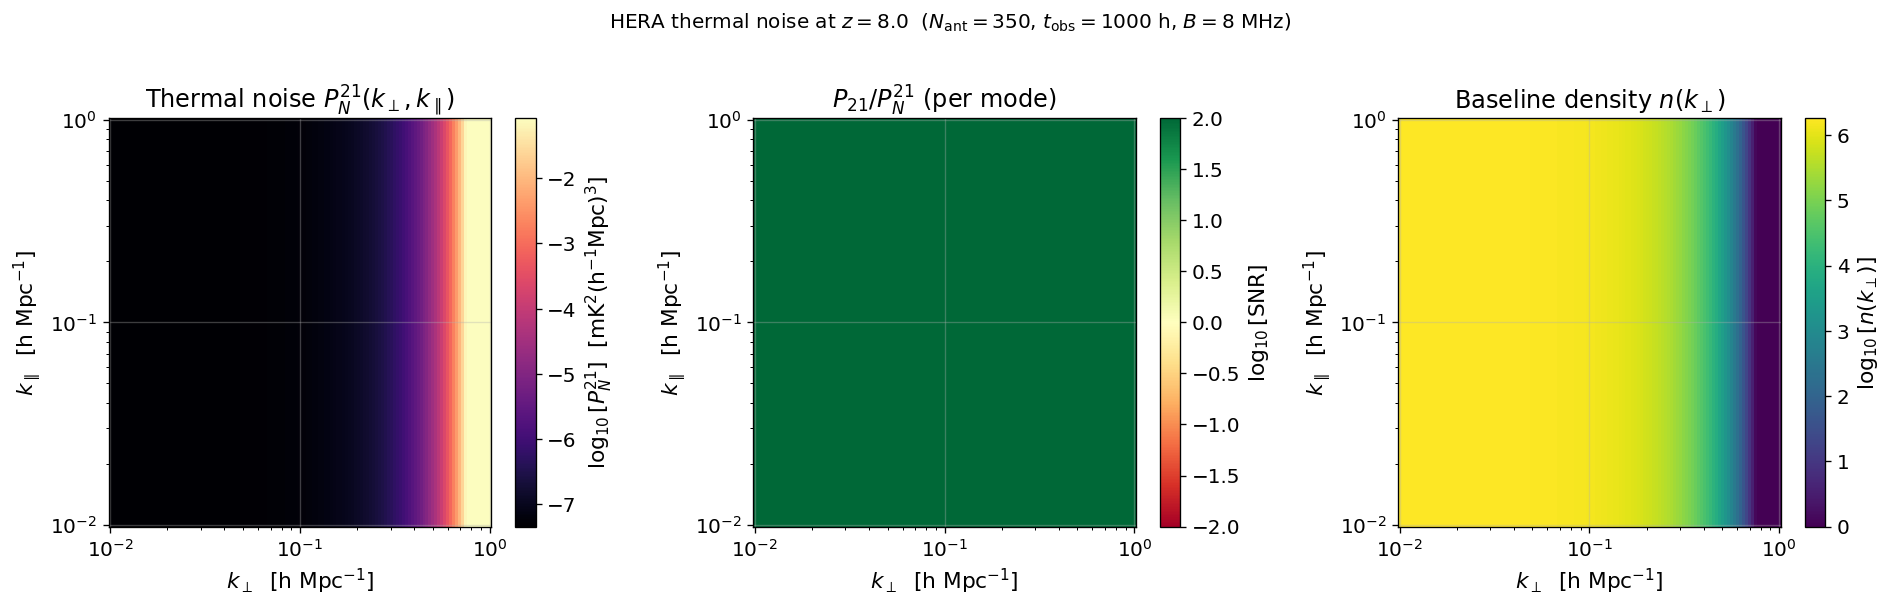

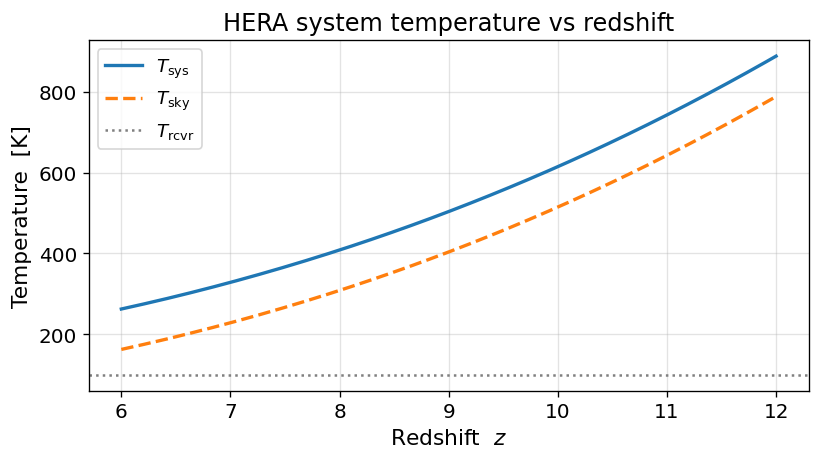

In [11]:
# ── Section 3d: HERA thermal noise — La Plante et al. (2023), Equation 11 ────

# ── Physical constants ────────────────────────────────────────────────────────
c_ms    = 3e8           # speed of light [m/s]
nu_21   = 1.4204e9      # rest frequency of 21cm line [Hz]
lambda_21 = c_ms / nu_21  # rest wavelength [m]  ~0.211 m

# ── HERA Phase II parameters (DeBoer et al. 2017; La Plante et al. 2023) ──────
N_ant    = 350          # number of antennas (full Phase II)
D_dish   = 14.0         # dish diameter [m]
eta_ap   = 0.7          # aperture efficiency
A_e      = eta_ap * np.pi * (D_dish / 2.0)**2   # effective collecting area [m^2]
T_rcvr   = 100e3        # receiver temperature [mK]  (100 K)
t_obs    = 1000.0 * 3600.0   # total integration time [s]  (1000 hours)
B_MHz    = 8.0          # bandwidth [MHz]
B        = B_MHz * 1e6  # bandwidth [Hz]

# ── Redshift-dependent quantities ─────────────────────────────────────────────
nu_obs   = nu_21 / (1.0 + z_obs)               # observed frequency [Hz]
lambda_obs = c_ms / nu_obs                     # observed wavelength [m]

# Sky temperature (synchrotron dominated at EoR frequencies)
# T_sky = 60 K * (300 MHz / nu_obs_MHz)^2.55    [Kelvin]
T_sky    = 60e3 * (300e6 / nu_obs)**2.55       # [mK]
T_sys    = T_rcvr + T_sky                      # total system temperature [mK]

print(f"At z = {z_obs}:")
print(f"  nu_obs   = {nu_obs/1e6:.2f} MHz")
print(f"  lambda_obs = {lambda_obs:.3f} m")
print(f"  T_sky    = {T_sky/1e3:.0f} K")
print(f"  T_rcvr   = {T_rcvr/1e3:.0f} K")
print(f"  T_sys    = {T_sys/1e3:.0f} K")

# ── Comoving distance D_C(z) via numerical integration ───────────────────────
def D_C(z, n_steps=1000):
    """
    Comoving distance D_C(z) [h^-1 Mpc] via trapezoidal integration.
    """
    z_int = np.linspace(0, z, n_steps)
    integrand = c_ms / 1e3 / H_z(z_int)  # c[km/s] / H(z)[km/s/Mpc] = Mpc
    return np.trapz(integrand, z_int) * h_cosmo   # convert to h^-1 Mpc

# Comoving distance conversion factors (Parsons et al. 2012)
X   = D_C(z_obs)                                    # [h^-1 Mpc / rad]
Y   = (c_ms/1e3 * (1.0 + z_obs)**2) / (H_z(z_obs) * nu_21 / 1e6) * h_cosmo
# Y = c [km/s] * (1+z)^2 / (H(z) [km/s/Mpc] * nu_21 [MHz]) * h  [h^-1 Mpc / Hz]
# Note: nu_21 in MHz to match H in km/s/Mpc
Y   = (c_ms/1e3 * (1.0 + z_obs)**2 / (H_z(z_obs) * nu_21)) * h_cosmo

print(f"\nConversion factors:")
print(f"  X = D_C(z={z_obs}) = {X:.2f} h^-1 Mpc / rad")
print(f"  Y = {Y:.4e} h^-1 Mpc / Hz")

# ── Primary beam solid angle ──────────────────────────────────────────────────
# Omega' = lambda_obs^2 / A_e  (Parsons et al. 2012 approximation)
Omega_prime = lambda_obs**2 / A_e                   # [sr]

# ── Baseline density model for HERA compact hexagonal core ───────────────────
# n(k_perp): number of baselines sampling k_perp
#
# Model: Gaussian in k_perp, peaked at k_perp = 0, falling off at the
# edge of the core (k_perp ~ 2*pi / (lambda_obs * D_array / X))
#
# Physical array diameter: N_side * D_dish where N_side ~ sqrt(N_ant)
N_side   = np.sqrt(N_ant)            # effective side length in dish units
D_array  = N_side * D_dish           # physical array diameter [m]

# Maximum baseline in units of wavelength
u_max    = D_array / lambda_obs

# Core k_perp scale:  k_perp_core = 2*pi * u_max / X
k_perp_core = 2.0 * np.pi * u_max / X   # [h/Mpc]

# Minimum k_perp (one dish separation):
k_perp_min = 2.0 * np.pi * (D_dish / lambda_obs) / X  # [h/Mpc]

print(f"\nHERA array geometry:")
print(f"  D_array  = {D_array:.1f} m,   u_max = {u_max:.1f}")
print(f"  k_perp_core = {k_perp_core:.4f} h/Mpc")
print(f"  k_perp_min  = {k_perp_min:.4f} h/Mpc")

def n_baselines(k_perp_2d):
    """
    Approximate number of HERA baselines measuring k_perp.

    Uses a Gaussian model for the compact core, which drops off
    sharply beyond the maximum baseline of the array.

    Parameters
    ----------
    k_perp_2d : array  -- k_perp values [h/Mpc]

    Returns
    -------
    n : array, same shape  (floored at 1 to avoid division by zero)
    """
    n_max = N_ant * (N_ant - 1) / 2.0 * (A_e / lambda_obs**2)
    n = n_max * np.exp(-k_perp_2d**2 / (2.0 * k_perp_core**2))
    # Zero out modes below the minimum baseline
    n = np.where(k_perp_2d < k_perp_min, 0.0, n)
    return np.clip(n, 1.0, None)   # floor at 1 to avoid division by zero


# ── Thermal noise power spectrum (La Plante et al. 2023, Eq. 11) ─────────────
def P_noise_21(k_perp_2d):
    """
    HERA thermal noise power spectrum P_N^21(k_perp, k_par) [mK^2 (h^-1 Mpc)^3].

    La Plante et al. (2023) Equation 11:
        P_N = T_sys^2 * X^2 * Y * Omega' / (B * t_obs * n(k_perp))

    Note: k_par-independent (white noise in frequency).

    Parameters
    ----------
    k_perp_2d : array  -- k_perp grid [h/Mpc], shape (N, N)

    Returns
    -------
    PN : array, same shape  [mK^2 (h^-1 Mpc)^3]
    """
    return (T_sys**2 * X**2 * Y * Omega_prime) / (B * t_obs * n_baselines(k_perp_2d))


# ── Evaluate on the full 2D grid ──────────────────────────────────────────────
# k_perp grid: first axis of k_perp is k_perp_1d broadcast across (N, N)
P21_noise = P_noise_21(k_perp)   # shape (N, N)   replaces the proxy power law

print(f"\nP_N^21 at k_perp = k_par = {k_perp_1d[N//4]:.3f} h/Mpc:")
print(f"  P21_noise = {P21_noise[N//4, N//4]:.2e}  mK^2 (h^-1 Mpc)^3")
print(f"  P21       = {P21[N//4, N//4]:.2e}  mK^2 (h^-1 Mpc)^3")
print(f"  SNR_single_mode ~ {np.abs(P21[N//4, N//4]) / P21_noise[N//4, N//4]:.3f}")

# ── Visualise P_N^21 on the 2D grid ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: noise power spectrum
im0 = axes[0].pcolormesh(k_perp_1d, k_par_1d,
                          np.log10(P21_noise.T), cmap="magma", shading="auto")
fig.colorbar(im0, ax=axes[0], label=r"$\log_{10}[P_N^{21}]$  [mK$^2$(h$^{-1}$Mpc)$^3$]")
axes[0].set_title(r"Thermal noise $P_N^{21}(k_\perp, k_\parallel)$")

# Panel 2: signal-to-noise per mode
SNR_map = np.abs(P21 / P21_noise)
im1 = axes[1].pcolormesh(k_perp_1d, k_par_1d,
                          np.log10(SNR_map.T), cmap="RdYlGn", shading="auto",
                          vmin=-2, vmax=2)
fig.colorbar(im1, ax=axes[1], label=r"$\log_{10}[\mathrm{SNR}]$")
axes[1].set_title(r"$P_{21} / P_N^{21}$ (per mode)")

# Panel 3: baseline density
im2 = axes[2].pcolormesh(k_perp_1d, k_par_1d,
                          np.log10(n_baselines(k_perp).T), cmap="viridis", shading="auto")
fig.colorbar(im2, ax=axes[2], label=r"$\log_{10}[n(k_\perp)]$")
axes[2].set_title(r"Baseline density $n(k_\perp)$")

for ax in axes:
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$k_\perp$  [h Mpc$^{-1}$]")
    ax.set_ylabel(r"$k_\parallel$  [h Mpc$^{-1}$]")

plt.suptitle(
    rf"HERA thermal noise at $z={z_obs}$  "
    rf"($N_{{\rm ant}}={N_ant}$, $t_{{\rm obs}}={t_obs/3600:.0f}$ h, "
    rf"$B={B_MHz:.0f}$ MHz)",
    y=1.01, fontsize=12
)
plt.tight_layout()
plt.show()

# ── T_sys evolution across EoR redshifts ──────────────────────────────────────
z_arr = np.linspace(6, 12, 200)
nu_arr = nu_21 / (1 + z_arr)
T_sky_arr = 60e3 * (300e6 / nu_arr)**2.55
T_sys_arr = T_rcvr + T_sky_arr

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z_arr, T_sys_arr/1e3, lw=2, label=r"$T_{\rm sys}$")
ax.plot(z_arr, T_sky_arr/1e3, lw=2, ls="--", label=r"$T_{\rm sky}$")
ax.axhline(T_rcvr/1e3, color="grey", ls=":", lw=1.5, label=r"$T_{\rm rcvr}$")
ax.set_xlabel("Redshift  $z$")
ax.set_ylabel("Temperature  [K]")
ax.set_title("HERA system temperature vs redshift")
ax.legend()
plt.tight_layout()
plt.show()

## 4  Variance of the galaxy power spectrum — Equation (17)

$$
\sigma^2_{\mathrm{gal}}
= \mathrm{var}\!\left[P_{\mathrm{gal}}(k_\perp, k_\parallel)\right]
= \Bigl[P_{\mathrm{gal}}(k_\perp, k_\parallel)
         + P^{\mathrm{noise}}_{\mathrm{gal}}(k_\parallel)\Bigr]^2
$$

This is the **cosmic-variance + shot-noise** formula for a Gaussian random field.
In the signal-dominated limit ($P_{\mathrm{gal}} \gg P^{\mathrm{noise}}_{\mathrm{gal}}$),
$\sigma_{\mathrm{gal}} \approx P_{\mathrm{gal}}$ (cosmic variance).  In the shot-noise
limit ($P^{\mathrm{noise}}_{\mathrm{gal}} \gg P_{\mathrm{gal}}$),
$\sigma_{\mathrm{gal}} \approx 1/\bar{n}$.

> **Note on mode counting:** Equations (15–17) are written for a *single* $(k_\perp, k_\parallel)$
> mode.  After averaging over $N_k$ independent modes in a bin the variance divides by $N_k$.
> We focus on the per-mode form here.


In [12]:
def sigma2_gal(P_gal, P_gal_noise):
    '''
    Per-mode variance of the galaxy auto-power-spectrum estimator.

    La Plante et al. (2023), Equation (17):

        sigma2_gal = [P_gal(k_perp, k_par) + P_gal_noise(k_par)]^2

    Parameters
    ----------
    P_gal       : array  -- galaxy signal power spectrum
    P_gal_noise : array  -- galaxy shot-noise power spectrum (= 1/n_bar)

    Returns
    -------
    sigma2 : array, same shape as inputs
    '''
    return (P_gal + P_gal_noise)**2


sig2_gal_arr = sigma2_gal(P_gal, P_gal_noise)
sig_gal_arr  = np.sqrt(sig2_gal_arr)   # standard deviation

print(f"sigma_gal at (k_perp, k_par) = (0.1, 0.1) h/Mpc : {sig_gal_arr[N//4, N//4]:.2e}")


sigma_gal at (k_perp, k_par) = (0.1, 0.1) h/Mpc : 7.11e+04


## 5  Variance of the 21 cm power spectrum — Equation (16)

$$
\sigma^2_{21}
= \mathrm{var}\!\left[P_{21}(k_\perp, k_\parallel)\right]
= \left[
      \frac{P_{21}(k_\perp, k_\parallel)}{T_0(z)^2}
    + \frac{P^{\mathrm{noise}}_{21}(k_\perp, k_\parallel)}{T_0(z)^2}
  \right]^2
$$

The $1/T_0^2$ factors convert from the simulation's brightness-temperature units to the
dimensionless fluctuations.  At high redshift, $T_0(z)$ is larger (see §2), which *suppresses*
the noise contribution relative to the signal — a favourable scaling for high-$z$ 21 cm
experiments.

$P^{\mathrm{noise}}_{21}$ (Eq. 11 of the paper) encodes the **thermal noise** of the HERA
interferometer; it grows steeply towards small scales (high $k$), eventually dominating the
error budget.


In [13]:
def sigma2_21(P21, P21_noise, T0_val):
    '''
    Per-mode variance of the 21 cm auto-power-spectrum estimator.

    La Plante et al. (2023), Equation (16):

        sigma2_21 = [(P21 + P21_noise) / T0^2]^2

    Parameters
    ----------
    P21       : array  -- 21 cm signal power spectrum  [mK^2 (h^-1 Mpc)^3]
    P21_noise : array  -- 21 cm thermal-noise spectrum [mK^2 (h^-1 Mpc)^3]
    T0_val    : float  -- T0(z)  [mK]

    Returns
    -------
    sigma2 : array, same shape as inputs
    '''
    return ((P21 + P21_noise) / T0_val**2)**2


sig2_21_arr = sigma2_21(P21, P21_noise, T0_val)
sig_21_arr  = np.sqrt(sig2_21_arr)   # standard deviation

print(f"T0(z={z_obs})^2 = {T0_val**2:.2f}  mK^2")
print(f"sigma_21 at (k_perp, k_par) = (0.1, 0.1) h/Mpc : {sig_21_arr[N//4, N//4]:.2e}")


T0(z=8.0)^2 = 629.04  mK^2
sigma_21 at (k_perp, k_par) = (0.1, 0.1) h/Mpc : 8.67e+03


## 6  Variance of the 21 cm × galaxy cross-power spectrum — Equation (15)

$$
\sigma^2_{21,\mathrm{gal}}
= \mathrm{var}\!\left[\frac{P_{21\times\mathrm{gal}}(k_\perp, k_\parallel)}{T_0(z)}\right]
= \frac{1}{2}\!\left[
      P^2_{21\times\mathrm{gal}}(k_\perp, k_\parallel)
    + \sigma_{21}(k_\perp, k_\parallel)\,\sigma_{\mathrm{gal}}(k_\perp, k_\parallel)
  \right]
$$

This follows from the **Isserlis–Wick theorem** applied to the four-point function of a
joint Gaussian field.  The two terms have distinct physical origins:

1. **Cross-spectrum squared** — cosmic variance: even in the absence of noise, the estimator
   scatters because we observe only a finite number of independent modes in the universe.
2. **Product of auto-spectrum standard deviations** — noise cross-contamination: thermal and
   shot noise from each individual field leak into the cross measurement.

At low $k$ (large scales), term 1 typically dominates.  At high $k$, term 2 dominates because
$\sigma_{21}$ (thermal noise) and/or $\sigma_{\mathrm{gal}}$ (shot noise) become large.


In [14]:
def sigma2_21_gal(P21_gal, sig_21, sig_gal, T0_val):
    '''
    Per-mode variance of the 21 cm x galaxy cross-power-spectrum estimator.

    La Plante et al. (2023), Equation (15).
    Derived originally in Lidz et al. (2009).

    The cross-spectrum P21_gal is defined in simulation units [mK (h^-1 Mpc)^3];
    the function divides by T0 internally to match the normalisation in Eq. 15.

        sigma2_cross = 0.5 * [(P21_gal/T0)^2 + sigma_21 * sigma_gal]

    Parameters
    ----------
    P21_gal : array  -- 21 cm x galaxy cross-spectrum  [mK (h^-1 Mpc)^3]
    sig_21  : array  -- std dev of 21 cm auto-spectrum  (sqrt of sigma2_21)
    sig_gal : array  -- std dev of galaxy auto-spectrum (sqrt of sigma2_gal)
    T0_val  : float  -- T0(z)  [mK]

    Returns
    -------
    sigma2 : array, same shape as inputs
    '''
    # Normalise cross-spectrum by T0 to go to dimensionless fluctuation units
    P21_gal_norm = P21_gal / T0_val
    return 0.5 * (P21_gal_norm**2 + sig_21 * sig_gal)


sig2_cross_arr = sigma2_21_gal(P21_gal, sig_21_arr, sig_gal_arr, T0_val)
sig_cross_arr  = np.sqrt(sig2_cross_arr)

print(f"sigma_cross at (k_perp, k_par) = (0.1, 0.1) h/Mpc : {sig_cross_arr[N//4, N//4]:.2e}")

# ── Break down the two terms of Eq. 15 ───────────────────────────────────────
term1 = 0.5 * (P21_gal / T0_val)**2        # cosmic variance of cross-spectrum
term2 = 0.5 * sig_21_arr * sig_gal_arr     # noise cross-contamination

ratio = term1 / (term1 + term2)
print(f"Fraction of sigma^2 from term1 (cosmic var.) at k=(0.1,0.1): {ratio[N//4, N//4]:.2%}")


sigma_cross at (k_perp, k_par) = (0.1, 0.1) h/Mpc : 2.47e+04
Fraction of sigma^2 from term1 (cosmic var.) at k=(0.1,0.1): 49.65%


## 7  Signal-to-noise ratio

The per-mode SNR of the cross-spectrum detection is

$$
\mathrm{SNR}(k_\perp, k_\parallel)
= \frac{\left|P_{21\times\mathrm{gal}}(k_\perp, k_\parallel)\,/\,T_0(z)\right|}
         {\sigma_{21,\mathrm{gal}}(k_\perp, k_\parallel)}
$$

Summing in quadrature over all independent modes gives the total detection significance:

$$
\mathrm{SNR}_{\mathrm{total}} = \sqrt{\sum_{k} \mathrm{SNR}^2(k_\perp, k_\parallel)}
$$


In [15]:
# Per-mode signal-to-noise ratio
SNR = np.abs(P21_gal / T0_val) / sig_cross_arr

# Total significance (sum in quadrature)
total_SNR = np.sqrt(np.sum(SNR**2))

print(f"Peak per-mode SNR          : {SNR.max():.2f}")
print(f"SNR at k=(0.1,0.1) h/Mpc  : {SNR[N//4, N//4]:.2f}")
print(f"Total significance (all modes, proxy grid) : {total_SNR:.1f} sigma")


Peak per-mode SNR          : 1.00
SNR at k=(0.1,0.1) h/Mpc  : 1.00
Total significance (all modes, proxy grid) : 116.0 sigma


### 7a  Overall Detectability

The total detection significance is obtained by summing the per-mode SNR in
quadrature over all independent Fourier modes, accounting for the number of
independent modes $N_k$ in each $(k_\perp, k_\parallel)$ cell of the survey
volume $V_{\rm survey}$:

$$
\mathrm{SNR}_{\rm total} = \sqrt{\sum_{k_\perp, k_\parallel}
N_k(k_\perp, k_\parallel) \, \mathrm{SNR}^2(k_\perp, k_\parallel)}
$$

where the mode count per cell is
$N_k = 2\pi\,k_\perp\,\Delta k_\perp\,\Delta k_\parallel\,V_{\rm survey}
/ (2\pi)^3$.

We report three summary statistics:
- **Total SNR** (all modes)
- **Cumulative SNR vs $k_{\max}$** — shows which scales drive the detection
- **Detection threshold** — conventionally $\mathrm{SNR}_{\rm total} > 5$
  for a confident detection


Survey volume: V = 1.15e+08 (h^-1 Mpc)^3

  DETECTABILITY SUMMARY  (z = 8.0)
  Peak per-mode SNR           : 0.998
  Median per-mode SNR         : 0.954
  Modes with SNR > 1          : 0 / 16384
  Total SNR (mode-weighted)   : 848.0 sigma
  Detection (SNR > 5)?        : YES


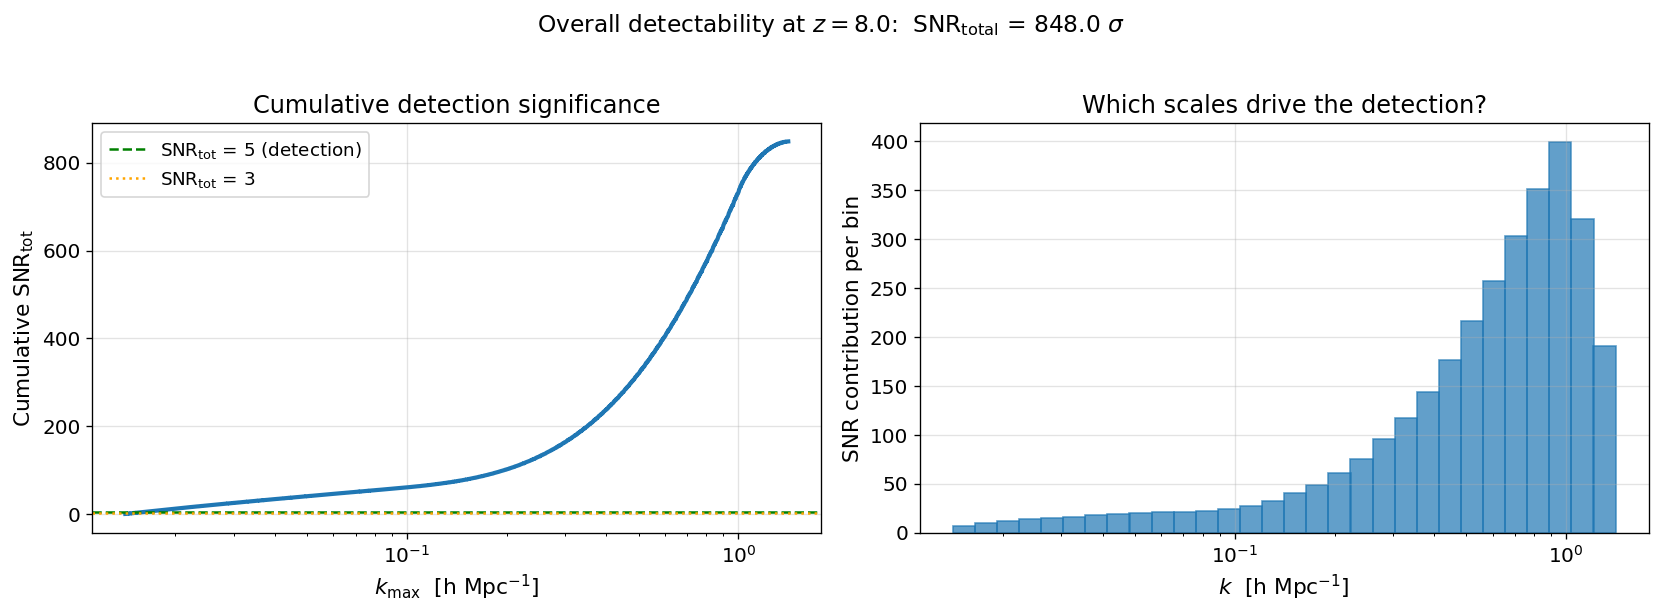

In [16]:
# ── Section 7a: Overall detectability ─────────────────────────────────────────

# ── Survey volume (La Plante et al. 2023, fiducial) ──────────────────────────
# Transverse: FoV ≈ Omega' * X^2;  LOS: bandwidth * Y
V_survey = Omega_prime * X**2 * (B * Y)  # [h^-3 Mpc^3]
print(f"Survey volume: V = {V_survey:.2e} (h^-1 Mpc)^3")

# ── Mode counting: N_k per (k_perp, k_par) cell ──────────────────────────────
# Annular shell in k_perp, slab in k_par
dk_perp = np.gradient(k_perp_1d)          # bin widths (non-uniform in log)
dk_par  = np.gradient(k_par_1d)
dk_perp_2d, dk_par_2d = np.meshgrid(dk_perp, dk_par, indexing='ij')

N_modes = (2 * np.pi * k_perp * dk_perp_2d * dk_par_2d) * V_survey / (2 * np.pi)**3
N_modes = np.clip(N_modes, 1, None)  # at least 1 mode per cell

# ── Total SNR with mode counting ──────────────────────────────────────────────
SNR_total = np.sqrt(np.sum(N_modes * SNR**2))

print(f"\n{'='*55}")
print(f"  DETECTABILITY SUMMARY  (z = {z_obs})")
print(f"{'='*55}")
print(f"  Peak per-mode SNR           : {SNR.max():.3f}")
print(f"  Median per-mode SNR         : {np.median(SNR):.3f}")
print(f"  Modes with SNR > 1          : {np.sum(SNR > 1)} / {SNR.size}")
print(f"  Total SNR (mode-weighted)   : {SNR_total:.1f} sigma")
print(f"  Detection (SNR > 5)?        : {'YES' if SNR_total > 5 else 'NO'}")
print(f"{'='*55}")

# ── Cumulative SNR vs k_max ───────────────────────────────────────────────────
# Sort all modes by k_tot, accumulate SNR^2
k_flat      = k_tot.ravel()
snr2_flat   = (N_modes * SNR**2).ravel()
sort_idx    = np.argsort(k_flat)
k_sorted    = k_flat[sort_idx]
cumul_snr   = np.sqrt(np.cumsum(snr2_flat[sort_idx]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: cumulative SNR vs k_max
axes[0].semilogx(k_sorted, cumul_snr, lw=2.5, color='C0')
axes[0].axhline(5,  color='green', ls='--', lw=1.5, label=r'SNR$_{\rm tot}$ = 5 (detection)')
axes[0].axhline(3,  color='orange', ls=':', lw=1.5, label=r'SNR$_{\rm tot}$ = 3')
axes[0].set_xlabel(r'$k_{\rm max}$  [h Mpc$^{-1}$]')
axes[0].set_ylabel(r'Cumulative SNR$_{\rm tot}$')
axes[0].set_title('Cumulative detection significance')
axes[0].legend()

# Panel 2: differential contribution — which k-bins drive the detection?
n_bins = 30
k_bin_edges = np.logspace(np.log10(k_flat.min()), np.log10(k_flat.max()), n_bins + 1)
snr2_binned = np.zeros(n_bins)
k_bin_centres = np.sqrt(k_bin_edges[:-1] * k_bin_edges[1:])

for b in range(n_bins):
    mask = (k_flat >= k_bin_edges[b]) & (k_flat < k_bin_edges[b + 1])
    snr2_binned[b] = np.sum(snr2_flat[mask])

axes[1].bar(k_bin_centres, np.sqrt(snr2_binned), 
            width=np.diff(k_bin_edges), align='center',
            color='C0', alpha=0.7, edgecolor='C0')
axes[1].set_xscale('log')
axes[1].set_xlabel(r'$k$  [h Mpc$^{-1}$]')
axes[1].set_ylabel(r'SNR contribution per bin')
axes[1].set_title('Which scales drive the detection?')

plt.suptitle(
    rf'Overall detectability at $z = {z_obs}$:  '
    rf'SNR$_{{\rm total}}$ = {SNR_total:.1f} $\sigma$',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()


### 7b  Uncertainty Budget with Photo-$z$ Errors

We now recompute the three uncertainty equations (La Plante et al. 2023, Eqs. 15–17) using the
photo-$z$-smeared observed spectra $P_\mathrm{gal}^\mathrm{obs}$ and
$P_{21\times\mathrm{gal}}^\mathrm{obs}$ from Section 3b.

The equations themselves are unchanged; only their inputs differ:

$$
\sigma^2_\mathrm{gal} = \left[P_\mathrm{gal}^{\rm obs}(k) + P_\mathrm{gal}^\mathrm{noise}\right]^2
\quad \text{(Eq. 17, with smeared } P_\mathrm{gal})
$$

$$
\sigma^2_{21,\mathrm{gal}} = \frac{1}{2}\left[\left(\frac{P_{21\times\mathrm{gal}}^{\rm obs}}{T_0}\right)^{\!2}
+ \sigma_{21}\,\sigma_\mathrm{gal}\right]
\quad \text{(Eq. 15, with smeared } P_{21\times\mathrm{gal}})
$$

The **SNR per mode** becomes

$$
\mathrm{SNR}(k_\perp, k_\parallel) =
\frac{|P_{21\times\mathrm{gal}}^\mathrm{obs}| / T_0}{\sigma_{21,\mathrm{gal}}}
= \frac{|P_{21\times\mathrm{gal}}|\,W(k_\parallel) / T_0}{\sigma_{21,\mathrm{gal}}}
$$

Both the numerator (signal) and denominator (noise) are suppressed by $W$, but not equally —
the noise also depends on $\sigma_\mathrm{gal}$, which is suppressed by $W^2$.  The net effect
is a **reduction in total SNR** that worsens with increasing $\sigma_z$ and is most severe at
high $k_\parallel$.

### References
- **La Plante et al. (2023)** — [arXiv:2205.09770](https://arxiv.org/abs/2205.09770) — Eqs. 15–17
  and discussion of Roman photo-$z$ requirements for cross-correlation detection (Section 4.3)
- **Lidz et al. (2009)** — [arXiv:0806.1055](https://arxiv.org/abs/0806.1055) — original
  derivation of the cross-spectrum variance estimator (Eqs. 15–17)
- **Wyithe & Loeb (2007)** — [arXiv:astro-ph/0612566](https://arxiv.org/abs/astro-ph/0612566)
  — forecasts for 21cm–galaxy cross-correlation SNR including survey design trade-offs

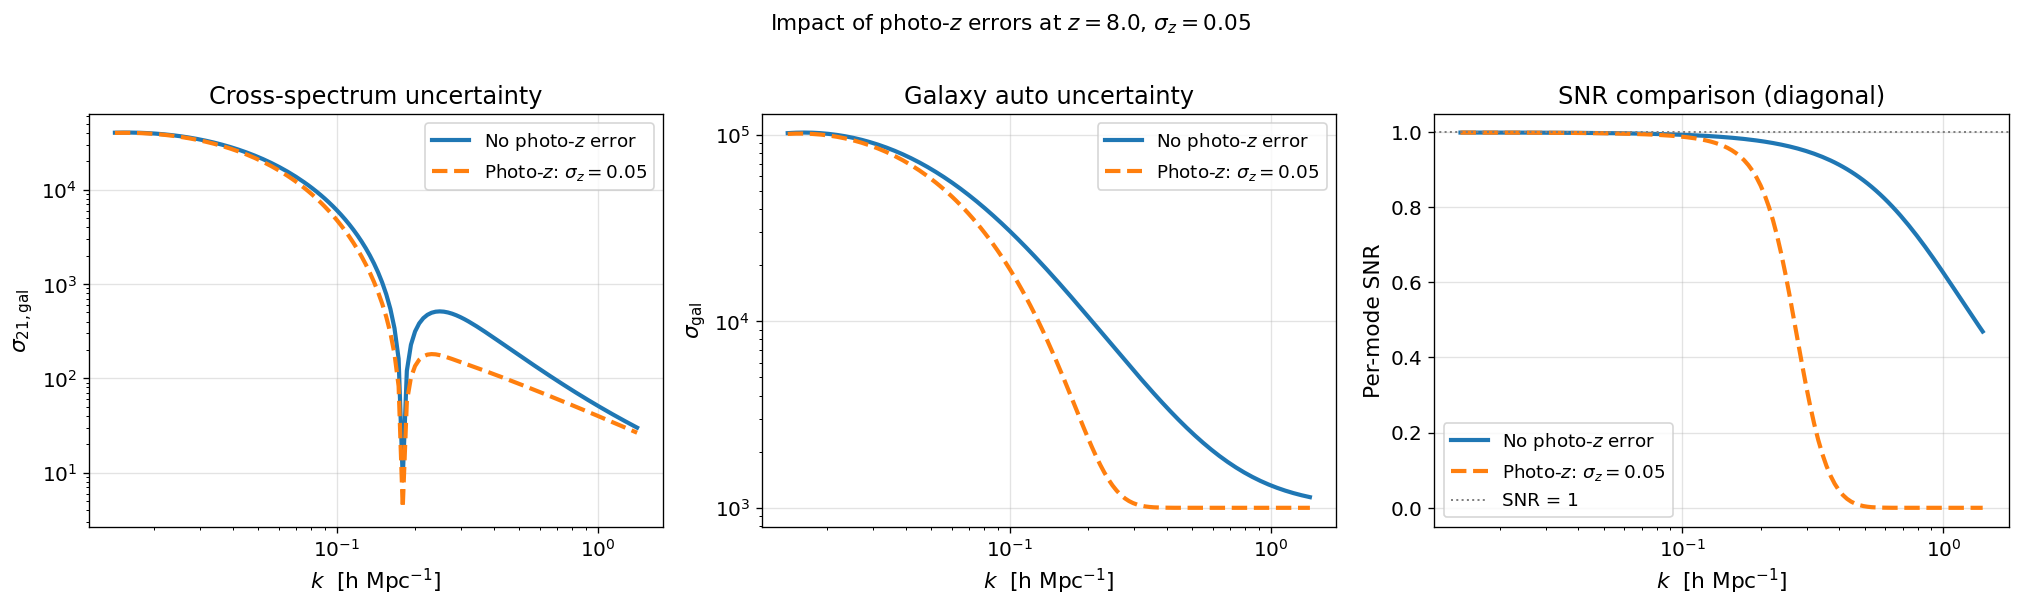

Total SNR without photo-z : 116.0 sigma
Total SNR with    photo-z : 93.5 sigma
SNR degradation           : 1.24x


In [17]:
# ── Section 7b: Recompute uncertainty budget with photo-z smearing ────────────

# Galaxy auto uncertainty: uses P_gal_obs (smeared)
sig2_gal_phz  = sigma2_gal(P_gal_obs, P_gal_noise)
sig_gal_phz   = np.sqrt(sig2_gal_phz)

# 21cm auto uncertainty: unchanged (21cm not affected by photo-z)
sig2_21_phz   = sigma2_21(P21, P21_noise, T0_val)
sig_21_phz    = np.sqrt(sig2_21_phz)

# Cross uncertainty: uses P21_gal_obs (smeared by one factor of W)
sig2_cross_phz = sigma2_21_gal(P21_gal_obs, sig_21_phz, sig_gal_phz, T0_val)
sig_cross_phz  = np.sqrt(sig2_cross_phz)

# SNR with photo-z
SNR_phz = np.abs(P21_gal_obs / T0_val) / sig_cross_phz

# ── Comparison plot: with vs without photo-z errors ──────────────────────────
diag_idx = np.arange(N)
k_diag   = k_tot[diag_idx, diag_idx]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: cross uncertainty
axes[0].loglog(k_diag, sig_cross_arr[diag_idx, diag_idx],
               lw=2.5, label="No photo-$z$ error")
axes[0].loglog(k_diag, sig_cross_phz[diag_idx, diag_idx],
               lw=2.5, ls='--', label=rf"Photo-$z$: $\sigma_z={sigma_z_phot}$")
axes[0].set_xlabel(r"$k$  [h Mpc$^{-1}$]")
axes[0].set_ylabel(r"$\sigma_{21,{\rm gal}}$")
axes[0].set_title("Cross-spectrum uncertainty")
axes[0].legend()

# Panel 2: galaxy uncertainty
axes[1].loglog(k_diag, sig_gal_arr[diag_idx, diag_idx],
               lw=2.5, label="No photo-$z$ error")
axes[1].loglog(k_diag, sig_gal_phz[diag_idx, diag_idx],
               lw=2.5, ls='--', label=rf"Photo-$z$: $\sigma_z={sigma_z_phot}$")
axes[1].set_xlabel(r"$k$  [h Mpc$^{-1}$]")
axes[1].set_ylabel(r"$\sigma_{\rm gal}$")
axes[1].set_title("Galaxy auto uncertainty")
axes[1].legend()

# Panel 3: SNR comparison
axes[2].semilogx(k_diag, SNR[diag_idx, diag_idx],
                 lw=2.5, label="No photo-$z$ error")
axes[2].semilogx(k_diag, SNR_phz[diag_idx, diag_idx],
                 lw=2.5, ls='--', label=rf"Photo-$z$: $\sigma_z={sigma_z_phot}$")
axes[2].axhline(1, color='grey', ls=':', lw=1.2, label='SNR = 1')
axes[2].set_xlabel(r"$k$  [h Mpc$^{-1}$]")
axes[2].set_ylabel("Per-mode SNR")
axes[2].set_title("SNR comparison (diagonal)")
axes[2].legend()

plt.suptitle(
    rf"Impact of photo-$z$ errors at $z={z_obs}$, $\sigma_z={sigma_z_phot}$",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

total_SNR_phz = np.sqrt(np.sum(SNR_phz**2))
print(f"Total SNR without photo-z : {np.sqrt(np.sum(SNR**2)):.1f} sigma")
print(f"Total SNR with    photo-z : {total_SNR_phz:.1f} sigma")
print(f"SNR degradation           : {np.sqrt(np.sum(SNR**2))/total_SNR_phz:.2f}x")

## 8  Diagnostic 2-D maps

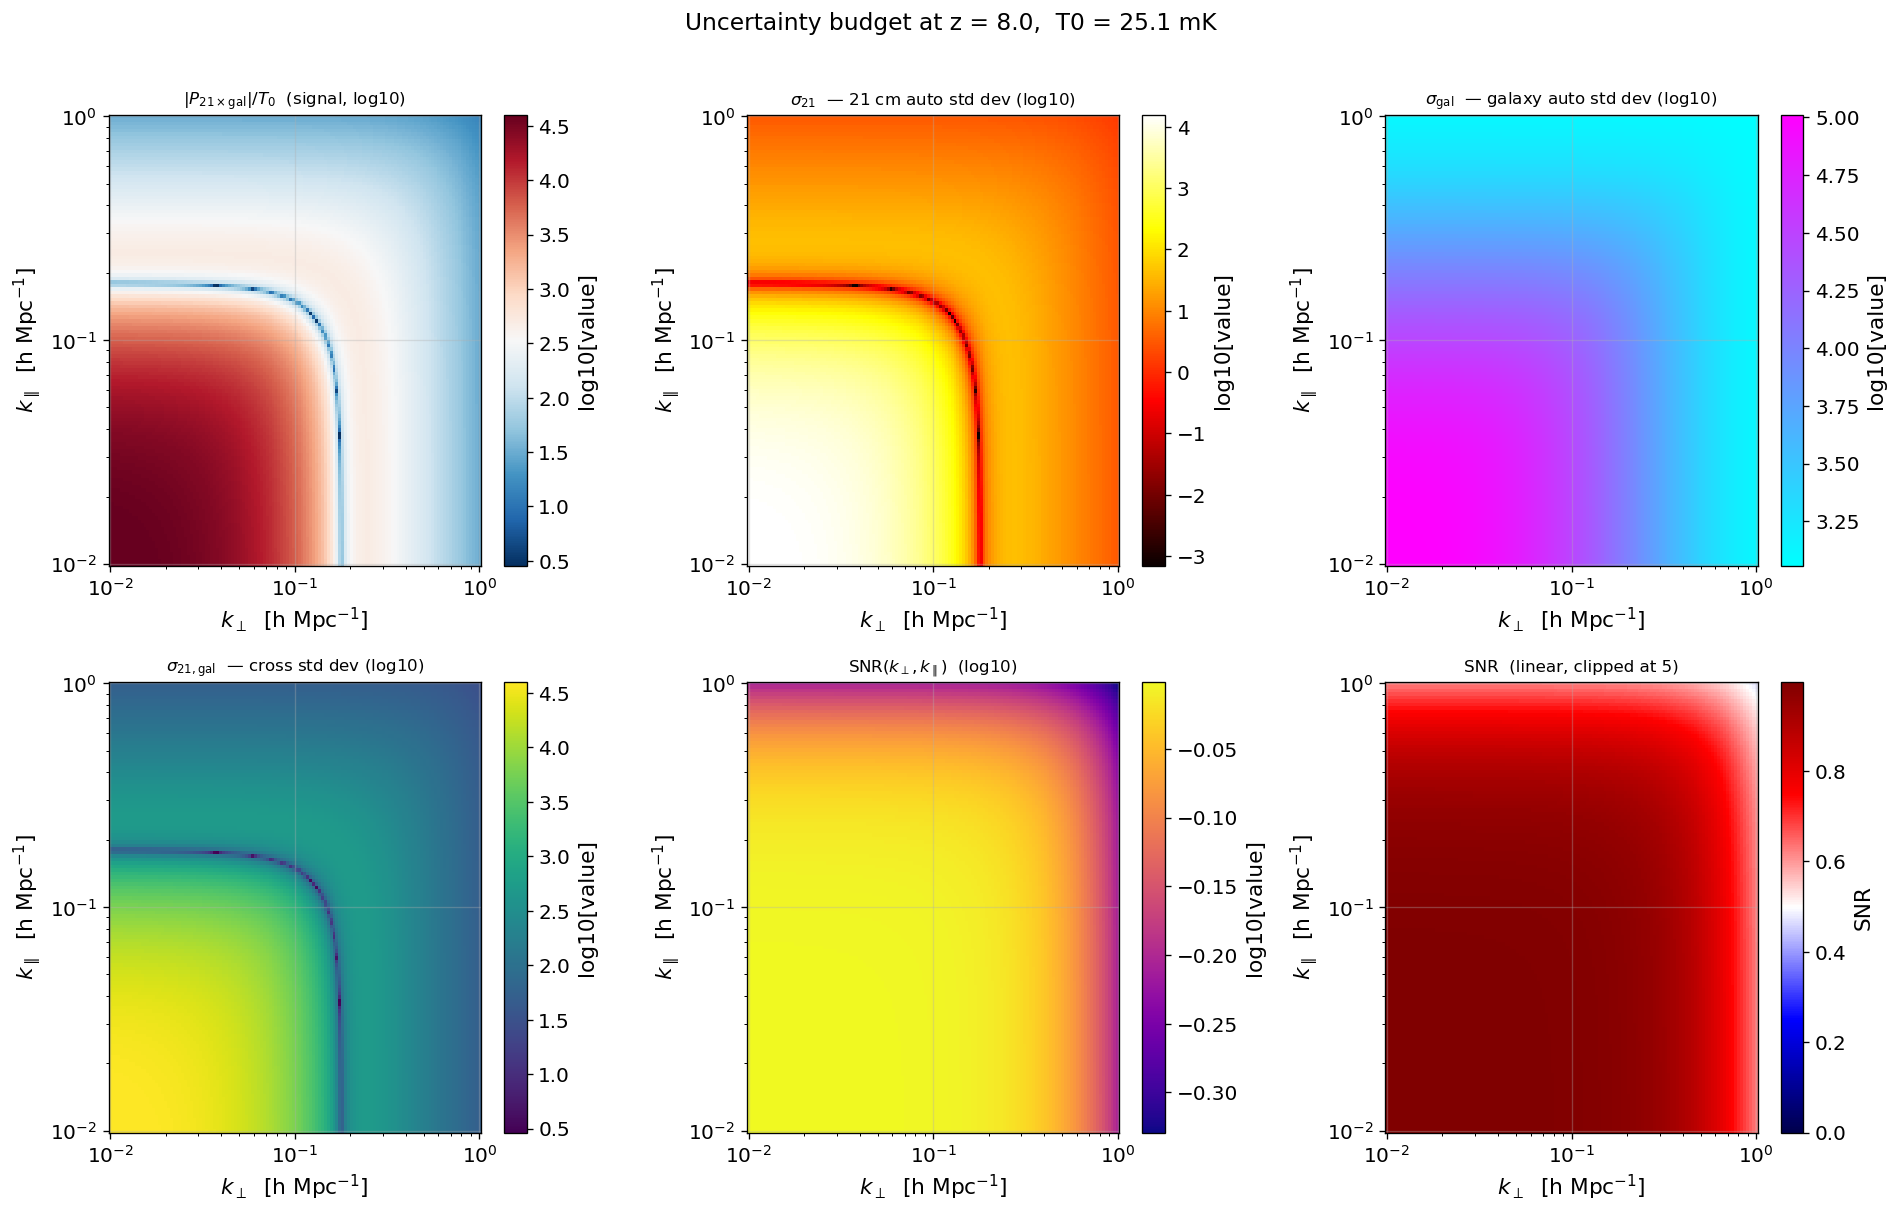

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

panels = [
    (np.abs(P21_gal / T0_val),
     r"$|P_{21\times{\rm gal}}|/T_0$  (signal, log10)", "RdBu_r"),
    (sig_21_arr,
     r"$\sigma_{21}$  — 21 cm auto std dev (log10)", "hot"),
    (sig_gal_arr,
     r"$\sigma_{\rm gal}$  — galaxy auto std dev (log10)", "cool"),
    (sig_cross_arr,
     r"$\sigma_{21,{\rm gal}}$  — cross std dev (log10)", "viridis"),
    (SNR,
     r"SNR$(k_\perp, k_\parallel)$  (log10)", "plasma"),
    (np.clip(SNR, 0, 5),
     r"SNR  (linear, clipped at 5)", "seismic"),
]

for ax, (data, title, cmap) in zip(axes.flat, panels):
    if "linear" in title:
        im = ax.pcolormesh(k_perp_1d, k_par_1d, data.T,
                           cmap=cmap, shading="auto", vmin=0)
        cb = fig.colorbar(im, ax=ax)
        cb.set_label("SNR")
    else:
        im = ax.pcolormesh(k_perp_1d, k_par_1d, np.log10(data.T),
                           cmap=cmap, shading="auto")
        cb = fig.colorbar(im, ax=ax)
        cb.set_label("log10[value]")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$k_\perp$  [h Mpc$^{-1}$]")
    ax.set_ylabel(r"$k_\parallel$  [h Mpc$^{-1}$]")
    ax.set_title(title, fontsize=10)

plt.suptitle(
    f"Uncertainty budget at z = {z_obs},  T0 = {T0_val:.1f} mK",
    y=1.01, fontsize=14
)
plt.tight_layout()
plt.show()


## 9  1-D slices along the diagonal $k_\perp = k_\parallel$

Cutting along the diagonal $k_\perp = k_\parallel = k/\sqrt{2}$ gives a clean 1-D view of
how each uncertainty term scales with total wavenumber $k$.  At large scales (small $k$) the
cross-signal dominates; at small scales, thermal and shot noise take over.


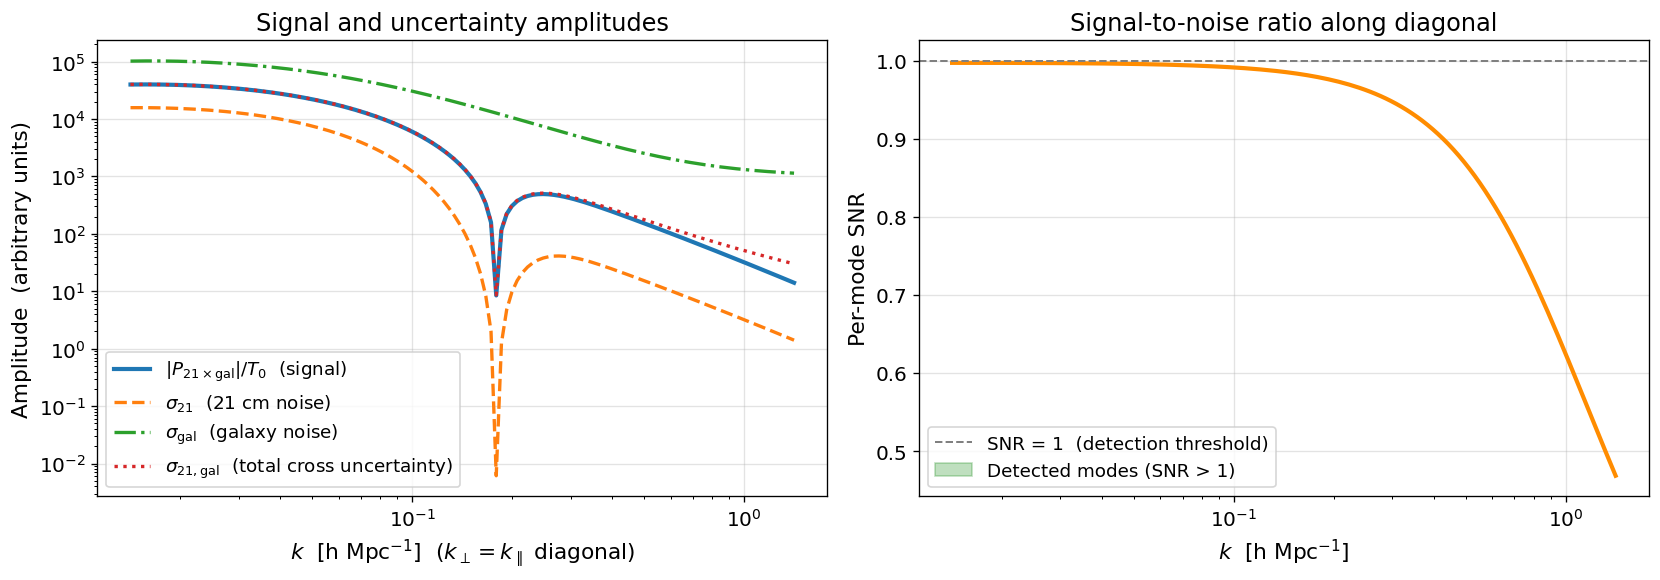

In [19]:
# The grid is square and log-spaced, so diagonal indices simply match
diag_idx = np.arange(N)
k_diag   = k_tot[diag_idx, diag_idx]

signal_diag    = np.abs(P21_gal[diag_idx, diag_idx] / T0_val)
sig_21_diag    = sig_21_arr[diag_idx, diag_idx]
sig_gal_diag   = sig_gal_arr[diag_idx, diag_idx]
sig_cross_diag = sig_cross_arr[diag_idx, diag_idx]
SNR_diag       = SNR[diag_idx, diag_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left panel: amplitudes ────────────────────────────────────────────────────
ax1.loglog(k_diag, signal_diag,    lw=2.5, label=r"$|P_{21\times{\rm gal}}|/T_0$  (signal)")
ax1.loglog(k_diag, sig_21_diag,    lw=2, ls="--",
           label=r"$\sigma_{21}$  (21 cm noise)")
ax1.loglog(k_diag, sig_gal_diag,   lw=2, ls="-.",
           label=r"$\sigma_{\rm gal}$  (galaxy noise)")
ax1.loglog(k_diag, sig_cross_diag, lw=2, ls=":",
           label=r"$\sigma_{21,{\rm gal}}$  (total cross uncertainty)")
ax1.set_xlabel(r"$k$  [h Mpc$^{-1}$]  ($k_\perp = k_\parallel$ diagonal)")
ax1.set_ylabel("Amplitude  (arbitrary units)")
ax1.set_title("Signal and uncertainty amplitudes")
ax1.legend(loc="best")

# ── Right panel: SNR ──────────────────────────────────────────────────────────
ax2.semilogx(k_diag, SNR_diag, lw=2.5, color="darkorange")
ax2.axhline(1, color="grey", ls="--", lw=1.2, label="SNR = 1  (detection threshold)")
ax2.fill_between(k_diag, SNR_diag, 1,
                 where=(SNR_diag >= 1),
                 alpha=0.25, color="green", label="Detected modes (SNR > 1)")
ax2.set_xlabel(r"$k$  [h Mpc$^{-1}$]")
ax2.set_ylabel("Per-mode SNR")
ax2.set_title("Signal-to-noise ratio along diagonal")
ax2.legend()

plt.tight_layout()
plt.show()


## 10  Redshift evolution of the uncertainty at a fixed mode

$T_0(z)$ grows with redshift (see §2), so the 21 cm thermal-noise contribution
($\propto 1/T_0^2$) is *suppressed* at higher $z$.  Here we track all three
uncertainties as a function of redshift at a single representative mode.


Representative mode: k_perp = 0.046,  k_par = 0.046  h/Mpc


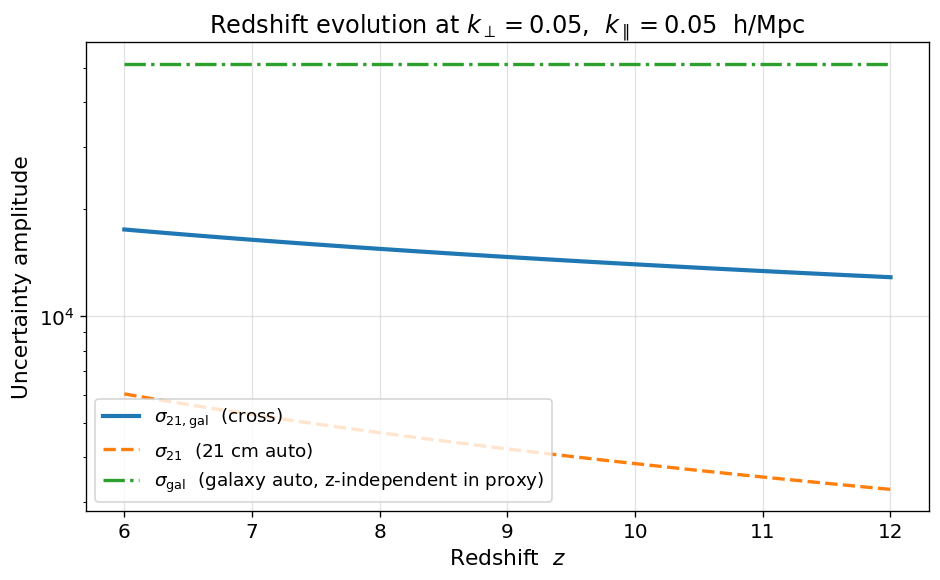

In [20]:
# Representative mode indices
i_rep, j_rep = N // 3, N // 3
k_rep_perp   = k_perp_1d[i_rep]
k_rep_par    = k_par_1d[j_rep]
print(f"Representative mode: k_perp = {k_rep_perp:.3f},  k_par = {k_rep_par:.3f}  h/Mpc")

z_range = np.linspace(6, 12, 100)

sig_cross_z = []
sig_21_z    = []
sig_gal_z   = []

for z_val in z_range:
    T0_z = T0(z_val)

    # 21 cm uncertainty (depends on z through T0)
    s21  = np.sqrt(sigma2_21(P21[i_rep, j_rep], P21_noise[i_rep, j_rep], T0_z))
    # Galaxy uncertainty (z-independent in this proxy model)
    sgal = np.sqrt(sigma2_gal(P_gal[i_rep, j_rep], P_gal_noise[i_rep, j_rep]))
    # Cross uncertainty
    scr  = np.sqrt(sigma2_21_gal(P21_gal[i_rep, j_rep], s21, sgal, T0_z))

    sig_21_z.append(s21)
    sig_gal_z.append(sgal)
    sig_cross_z.append(scr)

sig_21_z    = np.array(sig_21_z)
sig_gal_z   = np.array(sig_gal_z)
sig_cross_z = np.array(sig_cross_z)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(z_range, sig_cross_z, lw=2.5,
            label=r"$\sigma_{21,{\rm gal}}$  (cross)")
ax.semilogy(z_range, sig_21_z,    lw=2, ls="--",
            label=r"$\sigma_{21}$  (21 cm auto)")
ax.semilogy(z_range, sig_gal_z,   lw=2, ls="-.",
            label=r"$\sigma_{\rm gal}$  (galaxy auto, z-independent in proxy)")
ax.set_xlabel("Redshift  $z$")
ax.set_ylabel("Uncertainty amplitude")
ax.set_title(
    rf"Redshift evolution at $k_\perp={k_rep_perp:.2f}$,  "
    rf"$k_\parallel={k_rep_par:.2f}$  h/Mpc"
)
ax.legend()
plt.tight_layout()
plt.show()


### 10b  Redshift Evolution of SNR for Different Photo-$z$ Errors

We sweep over a range of photo-$z$ uncertainties $\sigma_z \in \{0, 0.02, 0.05, 0.1, 0.3\}$
and track how the cross-spectrum SNR evolves across the EoR ($6 \leq z \leq 12$) at a
representative Fourier mode.

Two competing redshift trends determine the shape of these curves:

1. **$T_0(z) \propto (1+z)^{1/2}$ grows with redshift** — this suppresses the 21 cm noise
   $\sigma_{21} \propto 1/T_0^2$, improving SNR at higher $z$

2. **$\sigma_r(z) = c\sigma_z/H(z)$ grows with redshift** — because $H(z)$ increases more
   slowly than $(1+z)$ at EoR redshifts, $\sigma_r$ increases with $z$, making photo-$z$
   damping **worse** at higher redshift for fixed $\sigma_z$

The interplay between these two effects sets an **optimal redshift window** for each value of
$\sigma_z$.  For large photo-$z$ errors ($\sigma_z \gtrsim 0.1$), the damping can dominate and
erase the SNR gain from $T_0$ at high redshift.

Note that for Roman, the photo-$z$ performance is expected to be $\sigma_z/(1+z) \approx 0.02$,
which corresponds to $\sigma_z \approx 0.18$ at $z=8$ — making photo-$z$ control a critical
systematic for cross-correlation science at high redshift.

### References
- **La Plante et al. (2023)** — [arXiv:2205.09770](https://arxiv.org/abs/2205.09770) — Figure 6
  and Section 4.3 show the redshift dependence of cross-correlation SNR for Roman
- **Eifler et al. (2021)** — [arXiv:2004.05271](https://arxiv.org/abs/2004.05271) — Roman photo-$z$
  requirement: $\sigma_z/(1+z) < 0.02$ for cosmology science cases
- **Visbal & Loeb (2010)** — [arXiv:1010.4796](https://arxiv.org/abs/1010.4796) — redshift
  evolution of 21cm–galaxy cross-correlation forecasts

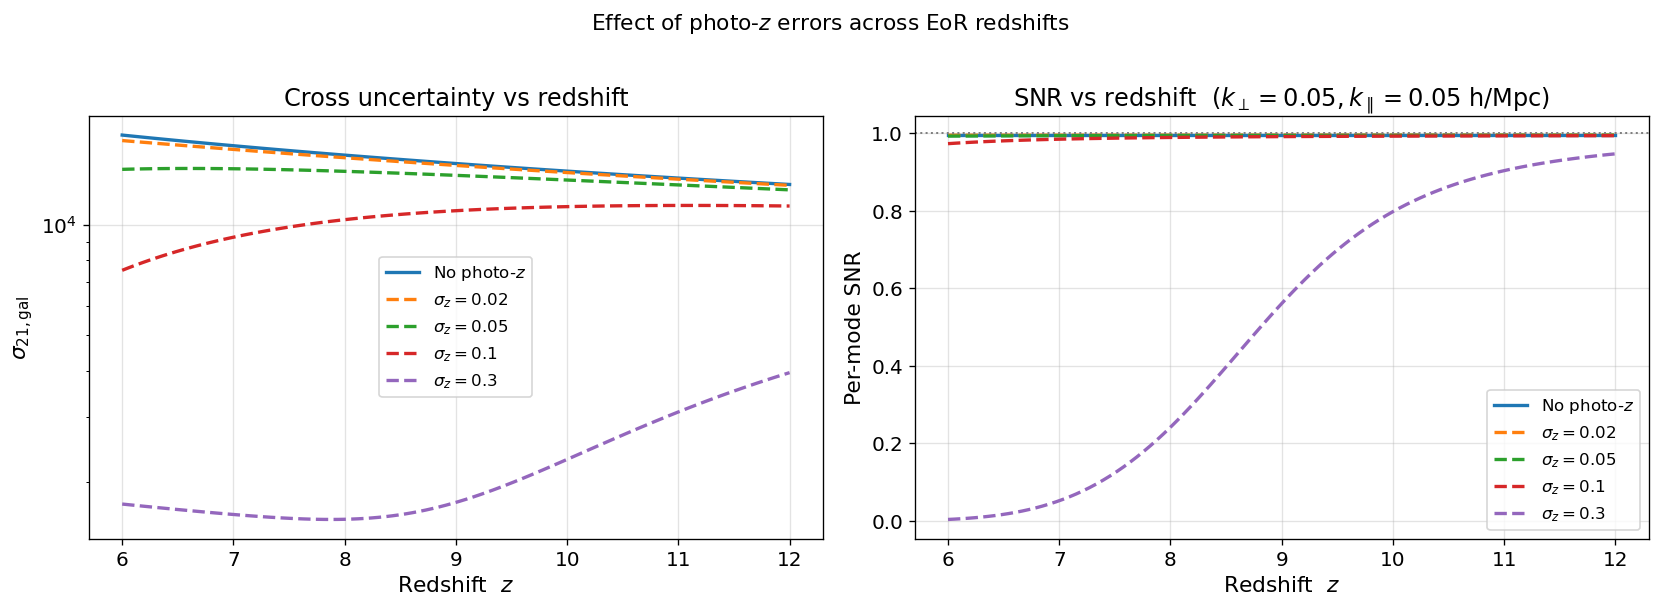

In [21]:
# ── Section 10b: Redshift evolution of uncertainty for different sigma_z ──────

sigma_z_values = [0.0, 0.02, 0.05, 0.1, 0.3]
z_range        = np.linspace(6, 12, 100)
i_rep, j_rep   = N // 3, N // 3   # representative mode

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sz in sigma_z_values:
    sig_cross_z_phz = []
    SNR_z_phz       = []

    for z_val in z_range:
        T0_z = T0(z_val)

        # Damping at this redshift and representative k_par
        w = W_photoz(k_par_1d[j_rep], z_val, sz)

        # Smeared spectra at representative mode
        p_gal_obs_rep   = P_gal[i_rep, j_rep]   * w**2
        p21_gal_obs_rep = P21_gal[i_rep, j_rep] * w

        s21  = np.sqrt(sigma2_21(P21[i_rep, j_rep], P21_noise[i_rep, j_rep], T0_z))
        sgal = np.sqrt(sigma2_gal(p_gal_obs_rep, P_gal_noise[i_rep, j_rep]))
        scr  = np.sqrt(sigma2_21_gal(p21_gal_obs_rep, s21, sgal, T0_z))
        snr  = np.abs(p21_gal_obs_rep / T0_z) / scr

        sig_cross_z_phz.append(scr)
        SNR_z_phz.append(snr)

    label = r"$\sigma_z = $" + f"{sz}" if sz > 0 else "No photo-$z$"
    ls    = '-' if sz == 0 else '--'
    axes[0].semilogy(z_range, sig_cross_z_phz, lw=2, ls=ls, label=label)
    axes[1].plot(z_range, SNR_z_phz,           lw=2, ls=ls, label=label)

axes[0].set_xlabel("Redshift  $z$")
axes[0].set_ylabel(r"$\sigma_{21,{\rm gal}}$")
axes[0].set_title("Cross uncertainty vs redshift")
axes[0].legend(fontsize=10)

axes[1].axhline(1, color='grey', ls=':', lw=1.2)
axes[1].set_xlabel("Redshift  $z$")
axes[1].set_ylabel("Per-mode SNR")
axes[1].set_title(rf"SNR vs redshift  ($k_\perp={k_rep_perp:.2f}, k_\parallel={k_par_1d[j_rep]:.2f}$ h/Mpc)")
axes[1].legend(fontsize=10)

plt.suptitle(r"Effect of photo-$z$ errors across EoR redshifts", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

W           = exp(-0.5 * k_par^2 * sigma_r^2)   # damping kernel
P_gal_obs   = P_gal   * W**2    # galaxy auto: both tracers smeared
P21_gal_obs = P21_gal * W       # cross: only galaxy side smeared

## 11  Summary and Next Steps

This notebook implements the **three uncertainty equations** from La Plante et al. (2023),
with three extensions: physically motivated signal power spectra (Lidz et al. 2009),
the HERA thermal noise model from Eq. 11 of the paper, and photometric redshift damping.

### Equations implemented

| Equation | Quantity | Physics |
|----------|----------|---------|
| (6)  | $T_0(z)$ | Converts simulation units to mK; grows as $(1+z)^{1/2}$ |
| (11) | $P_N^{21}(k_\perp, k_\parallel)$ | **HERA thermal noise** — new in this version |
| (17) | $\sigma^2_{\rm gal}$ | Shot-noise-dominated at $k \gtrsim 0.3\,h/$Mpc |
| (16) | $\sigma^2_{21}$ | Thermal-noise-dominated at high $k$; improves at high $z$ via $T_0$ |
| (15) | $\sigma^2_{21,{\rm gal}}$ | Combines both: cosmic-variance at low $k$, noise at high $k$ |

### Physical spectra (Sections 3a–3c, Lidz et al. 2009)

| Component | Model | Source |
|-----------|-------|--------|
| $P_m(k,z)$ | BBKS transfer function + $\sigma_8$ normalisation + $D(z)$ | Bardeen et al. (1986); Carroll et al. (1992) |
| $P_{21}(k)$ | $T_0^2\,x_{\rm HI}^2\,(b_\rho + b_x W_b)^2\,P_m$ | Lidz et al. (2009) Eq. 2 |
| $P_{\rm gal}(k)$ | $b_{\rm gal}^2\,P_m$ | Lidz et al. (2009) Eq. 3 |
| $P_{21\times{\rm gal}}(k)$ | $T_0\,x_{\rm HI}\,b_{\rm gal}(b_\rho + b_x W_b)\,P_m$ | Lidz et al. (2009) Eq. 5 |

### HERA thermal noise (Section 3d, La Plante et al. 2023 Eq. 11)

$$
P_N^{21}(k_\perp, k_\parallel) =
\frac{T_{\rm sys}^2 \, X^2 \, Y \, \Omega'}{B \, t_{\rm obs} \, n(k_\perp)}
$$

| Component | Description |
|-----------|-------------|
| $T_{\rm sys}(z)$ | $T_{\rm rcvr} + 60\,\mathrm{K}\,(300\,\mathrm{MHz}/\nu)^{2.55}$; sky-dominated |
| $X = D_C(z)$ | Transverse comoving distance [h$^{-1}$ Mpc / rad] |
| $Y = c(1+z)^2 / (H(z)\nu_{21})$ | LOS frequency-to-distance conversion [h$^{-1}$ Mpc / Hz] |
| $\Omega' = \lambda_{\rm obs}^2 / A_e$ | Effective primary beam [sr] |
| $n(k_\perp)$ | Baseline density: Gaussian core model for HERA hexagonal layout |

### Photo-$z$ extension (Sections 2b, 3b, 7b, 10b)

| Addition | Description |
|----------|-------------|
| $\sigma_r = c\sigma_z/H(z)$ | Comoving LOS smearing |
| $W(k_\parallel) = e^{-k_\parallel^2\sigma_r^2/2}$ | Gaussian damping kernel |
| $P_{\rm gal}^{\rm obs} = P_{\rm gal} W^2$ | Galaxy auto suppressed by $W^2$ |
| $P_{21\times{\rm gal}}^{\rm obs} = P_{21\times{\rm gal}} W$ | Cross suppressed by $W$ |

### To make this fully physical

1. **Replace the BBKS transfer function** with CAMB or CLASS outputs for exact BAO features
2. **Replace the baseline density model** with the true HERA hexagonal layout using
   [21cmSense](https://github.com/jpober/21cmSense) (Pober et al. 2014), which accounts
   for the precise $(u, v)$ coverage and fringe-rate filtering
3. **Apply the foreground wedge mask**: excise modes with
   $k_\parallel < k_\perp \sin\theta_{\rm horizon} + k_{\rm buffer}$; La Plante et al.
   (2023) use a 0.1 h/Mpc buffer beyond the horizon line
4. **Replace the bias model** with 21cmFAST outputs including the actual
   $P_{\rm xHI,gal}$, $P_{\rm \rho,gal}$ cross-terms
5. **Model photo-$z$ errors self-consistently** with $\sigma_z(z) = \sigma_0(1+z)$
   and marginalise over photo-$z$ bias
6. **Extend to a Fisher matrix forecast** for constraints on $\bar{x}_{\rm HI}(z)$
   and $R_b(z)$

### References

| Paper | Role |
|-------|------|
| La Plante et al. (2023) — [arXiv:2205.09770](https://arxiv.org/abs/2205.09770) | Uncertainty Eqs. 15–17; **thermal noise Eq. 11** |
| Lidz et al. (2009), ApJ 690 — [arXiv:0806.1055](https://arxiv.org/abs/0806.1055) | Physical signal spectra |
| Pober et al. (2014), ApJ 782 — [arXiv:1310.7031](https://arxiv.org/abs/1310.7031) | Interferometric noise formula |
| Parsons et al. (2012), ApJ 756 — [arXiv:1204.4749](https://arxiv.org/abs/1204.4749) | Comoving conversion factors $X$, $Y$ |
| McQuinn et al. (2006), ApJ 653 — [arXiv:astro-ph/0512263](https://arxiv.org/abs/astro-ph/0512263) | Original interferometer sensitivity formalism |
| DeBoer et al. (2017), PASP — [arXiv:1606.07473](https://arxiv.org/abs/1606.07473) | HERA instrument specs |
| Bardeen et al. (1986), ApJ 304 | BBKS transfer function |
| Carroll, Press & Turner (1992), ARA&A 30 | Growth factor and $D_C(z)$ |
| Planck Collaboration (2020) — [arXiv:1807.06209](https://arxiv.org/abs/1807.06209) | Cosmological parameters |
| Seo & Eisenstein (2003) — [arXiv:astro-ph/0307460](https://arxiv.org/abs/astro-ph/0307460) | Photo-$z$ LOS damping |
| Eifler et al. (2021) — [arXiv:2004.05271](https://arxiv.org/abs/2004.05271) | Roman photo-$z$ requirements |